In [ ]:
# Etap 0
#To o co prosił pan promotor - duplikaty i sprawdzenie czy czasy są takie same
import pandas as pd
import numpy as np
import json

df = pd.read_csv("/content/drive/MyDrive/Praca Magisterska/Statystyka opisowa/wynik.csv")

duplicates = df[df.duplicated(subset=["hash"], keep=False)]

duplicates = duplicates[
    ["modelId", "hash","status" , "internalName", "model_group", "pixel_count", "duration_seconds"]
].sort_values("hash")
duplicates = duplicates.sort_values("hash")
duplicates.head(20)

,modelId,hash,status,internalName,model_group,pixel_count,duration_seconds
13894,38b2b011-9e88-4355-acc9-af7bbc8ae6ba,0004bb4de3e4407488fdc683f2dc6cf9cd387bb62ec51f...,NEW,OXIDATION,OXIDATION,816426.0,8.833
9980,45c1cc41-aca0-4046-acae-5eb7089deeb6,0004bb4de3e4407488fdc683f2dc6cf9cd387bb62ec51f...,FAILED,INCLUSIONS,INCLUSIONS,816426.0,2.831
3288,012143b5-1ee3-4c2a-a1c7-55e8c952394c,001606896982a7d001776cc49f94acbce6cb657de57484...,NEW,GRAIN,GRAIN,3236400.0,40.056
3637,012143b5-1ee3-4c2a-a1c7-55e8c952394c,001606896982a7d001776cc49f94acbce6cb657de57484...,NEW,GRAIN,GRAIN,3236400.0,38.927
34410,d4bfa304-c296-475d-9c73-205108477e60,001a4f2606b9ede09955bc687dcaead00414f8a68020bc...,NEW,Nitride,NITRIDE,2354176.0,26.031
34120,d4bfa304-c296-475d-9c73-205108477e60,001a4f2606b9ede09955bc687dcaead00414f8a68020bc...,FAILED,Nitride,NITRIDE,2354176.0,3.081
11687,1408e17d-f5bc-479e-bdfe-0547a6035510,00256f08e572d669f8878878d506527d871150b333aa1c...,NEW,GRAIN_ZERO,GRAIN,1048576.0,14.374
11011,012143b5-1ee3-4c2a-a1c7-55e8c952394c,00256f08e572d669f8878878d506527d871150b333aa1c...,NEW,GRAIN,GRAIN,1048576.0,39.317
3993,012143b5-1ee3-4c2a-a1c7-55e8c952394c,002677bbf9da0e9568e02bf7b8887e92605551dbf99e04...,NEW,GRAIN,GRAIN,4976832.0,23.095
27364,012143b5-1ee3-4c2a-a1c7-55e8c952394c,002677bbf9da0e9568e02bf7b8887e92605551dbf99e04...,NEW,GRAIN,GRAIN,4976832.0,163.164


In [ ]:
# Etap 1 - wczytanie danych oraz przygotowanie gotowego pliku wynik.csv

In [ ]:
import pandas as pd
import numpy as np
import json

# Ścieżki do plików
JOB_PATH = "/content/drive/MyDrive/Praca Magisterska/Statystyka opisowa/JobInfo2.csv"
IMAGE_PATH = "/content/drive/MyDrive/Praca Magisterska/Statystyka opisowa/Image2.csv"
COMPUTE_MODEL_PATH = "/content/drive/MyDrive/Praca Magisterska/Statystyka opisowa/ComputeModel.csv"
COMPLEXITY_PATH = "/content/drive/MyDrive/Praca Magisterska/Statystyka opisowa/image_complexity.csv"


In [ ]:
#1. Wczytanie danych
df_job = pd.read_csv(JOB_PATH, sep=",")
df_image = pd.read_csv(IMAGE_PATH, sep=",")
df_compute_model = pd.read_csv(COMPUTE_MODEL_PATH, sep=",")
df_complexity = pd.read_csv(COMPLEXITY_PATH, sep=",")

print("JobInfo:", df_job.shape)
print("Image:", df_image.shape)
print("ComputeModel:", df_compute_model.shape)
print("Complexity:", df_complexity.shape)


JobInfo: (68193, 21)
Image: (42508, 13)
ComputeModel: (76, 10)
Complexity: (48784, 6)


In [ ]:
print("Wszystkie wiersze:", len(df_image))
print("Unikalne hashe:", df_image["hash"].nunique())
print("Duplikaty hashy:", len(df_image) - df_image["hash"].nunique())

Wszystkie wiersze: 42508
Unikalne hashe: 24318
Duplikaty hashy: 18190


In [ ]:
print("Wszystkie wiersze:", len(df_job))
print("Unikalne obrazy po id:", df_job["imageId"].nunique())
print("Duplikaty obrazow po id:", len(df_job) - df_job["imageId"].nunique())

Wszystkie wiersze: 68193
Unikalne obrazy po id: 26312
Duplikaty obrazow po id: 41881


In [ ]:
#2. Funkcja do pogrupowania modeli po ich internalName
def normalize_model_group(internal_name):
    if pd.isna(internal_name):
        return "UNKNOWN"

    name = str(internal_name).strip().upper()

    # Ujednolicenie znanych wariantów nazewnictwa
    name = name.replace(" ", "")
    name = name.replace("-", "_")


    if name.startswith("CARBIDES"):
        return "CARBIDES"
    if name.startswith("CRACKS"):
        return "CRACKS"
    if name.startswith("DARK_VAC"):
        return "DARK_VAC"
    if name.startswith("DECARBURIZATION"):
        return "DECARBURIZATION"
    if name.startswith("DEND"):
        return "DENDRITES"
    if name.startswith("FERRITE"):
        return "FERRITE"
    if name.startswith("GRAIN"):
        return "GRAIN"
    if name.startswith("GROUND"):
        return "GROUND"
    if name.startswith("LAYER"):
        return "LAYER"
    if name.startswith("MAGNIFICATION"):
        return "MAGNIFICATION" #do wyrzucenia
    if name.startswith("MARTENSITE"):
        return "MARTENSITE"
    if name.startswith("OXI"):
        return "OXIDATION"
    if name.startswith("PEARLITE"):
        return "PEARLITE"
    if name.startswith("RETAINED"):
        return "RETAINED_AUSTENITE"
    if name.startswith("SEGMENT"):
        return "SEGMENT" #do wyrzucenia


    #wyrzucone zostały te magnification i segment całkowicie z bazy ponieważ z tego co mówił Pan promotor są one częścią innych modeli a więc nie ma sensu ich kilka razy liczyć

    #do sprawdzenia dodanie complexity i jak wpływa na statystykę / obliczenia - plik, który dostałem od Pana promotora wykorzystuja obrazy do liczenia tego lvDecay, compression ratio ,comlpexity itd. Żebym mógł sobie policzyć najlepiej skorelowane comlpexity potrzebował bym fizycznie obraz
    # a praca miała się jednak opierać o dane historyczne w plikach csv :/. W tym pliku panowie zamieniają obraz na tablicę odcieni szarości i na jej podstawie liczą w/w rzeczy. Żebym mógł to przepisać w pythonie (nawet z chatami/ cloudami) to musiałbym mieć obrazy aby móc je wykorzystać jako input do funkcji
    #bez obrazu tego kodu nie da się przepisać tak, żeby liczył mi to comlpexity. Kod polega na analizowaniu piksela w sliding window (3 piksele w każdym kierunku) i dla każdego takiego okna coś tam liczą (nie rozumiem dokładnie co ale coś tam liczą jakieś wariancje inne takie).
    #a więc jak widać bez obrazów w formie .jpeg czy tam .png nie da się z tym kodem zrobić nic

    #do sprawdzenia czy ten sam obraz wykonuje się ten sam czas ----------------> nie wykonuje się ten sam czas. Niejednokrotnie ten sam obraz wykonywany przez ten sam model o tej samej wersji o tych samych wymiarach ma różne czasy (nie reaaz różnią się nawet o kilkadziesiąt sekund)

    #do sprawdzenia występowanie executorId i jak jest tego dużo to zrobienie z tego statystyki ----------> 40 tyś rekordów około - spróbowałem zrobić statystykę tylko dla rekordów, których  executorId nie jest NaN.
    # Nawet wyszło - mniej zadań o statusie fail, większy współczynnik determinacji dla pixel_count (width x height)
    # Co do modeli to wyszło minimalnie lepiej. Błedy procentowe od 70% - 28% ale to wynika z tego jak te dane wyglądają - lepiej już się naprawdę nie da - może dodanie tego complexity poprawiło by to o kilka punktów procentowych ale nie zrobi to kolosalnej różnicy

    #do zrobienia symulacja dla wszystkich rozwiązań na podstawie order (bierzemy pierwsze x zadań i sprawdzamy czas wykonania się ich full i robimy symulację i porównujemy ) - UWAGA muszą mieć tego samego ownera


    # Domyślnie: bierzemy nazwę przed pierwszym podkreśleniem
    return name.split("_")[0]

df_compute_model["model_group"] = df_compute_model["internalName"].apply(normalize_model_group)

model_map = df_compute_model[["id", "internalName", "model_group"]].rename(
    columns={"id": "modelId"}
)

print("Liczba modeli w ComputeModel:", len(df_compute_model))
print("\nPrzykładowe mapowanie modelId -> internalName -> model_group:")
print(model_map.head(20))

Liczba modeli w ComputeModel: 76

Przykładowe mapowanie modelId -> internalName -> model_group:
                                 modelId                internalName  \
0   d96802f5-3e25-4120-9bb0-b9f6efa84597         DECARBURIZATION_ALL   
1   f9e4aecb-31cf-4a62-86ba-07a9f06a676a                    CARBIDES   
2   93a4bb6e-743b-43e5-9b0a-096d1e9721a9          RETAINED_AUSTENITE   
3   5c574ca1-69d9-4fa0-85e7-594e7b50f7f5                   GRAIN_OLD   
4   4e063fe1-95c8-45a9-b3a0-140a31df762c                     FERRITE   
5   67e13cca-e327-4bd8-9161-fc1713bc59ac                 SEGMENT_ALL   
6   2960fa16-c7b4-4dd8-a70d-c7fddda4c217                     SEGMENT   
7   37755047-c0f4-4ba7-a298-f70fe50f0a41                CARBIDES_HTU   
8   bf6b12e4-6edd-4fe5-8511-7e315c894b43         DECARBURIZATION_WDI   
9   02103489-3959-4141-90cd-c7bc27deb056     DECARBURIZATION_ZOLLERN   
10  6983ded9-2a3b-4360-bef9-64ba6d41c030                 FERRITE_KRW   
11  54e6bf70-91d1-4faa-bbf3-701dbdd33b86

In [ ]:
#3. Funkcja rozbijająca meta na height, width oraz format
def parse_meta(value):
    """
    Zamienia:
    {"width": 1453, "format": "png", "height": 1027}
    ->
    width, height, format
    """
    try:
        data = json.loads(value)
        return pd.Series([
            data.get("width"),
            data.get("height"),
            data.get("format")
        ])
    except Exception:
        return pd.Series([None, None, None])

In [ ]:
# 4. Funkcja standaryzująca datę
def split_datetime(value):
    """
    Obsługuje np.:
    - 11.08.2025 20:09:41.088
    - 11/8/2025 20:09:41
    """
    if pd.isna(value):
        return pd.Series([None, None])

    value = str(value).strip()

    if "." in value:
        left, right = value.rsplit(".", 1)

        # jeśli po ostatniej kropce są same cyfry, traktujemy to jako milisekundy
        if right.isdigit():
            return pd.Series([left, int(right)])

    return pd.Series([value, 0])

In [ ]:
#5. Import najważniejszych kolumn
job_columns = [
    "id",
    "imageId",
    "status",
    "createdAt",
    "startedAt",
    "finishedAt",
    "modelId",
    "modelVersion",
    "executorId",
    "order",
    "ownerId",
    "projectId"
]

image_columns = [
    "id",
    "orginalFilename",
    "size",
    "createdAt",
    "hash",
    "meta"
]

df_job = df_job[job_columns]
df_image = df_image[image_columns]

print("Po wyborze kolumn:")
print("Job:", df_job.shape)
print("Image:", df_image.shape)


Po wyborze kolumn:
Job: (68193, 12)
Image: (42508, 6)


In [ ]:
#6. Rozbicie meta w Image
df_image.loc[:, ["width", "height", "format"]] = (df_image["meta"].apply(parse_meta).values)
#usunięcie meta
df_image = df_image.drop(columns=["meta"])

In [ ]:
#7. Usunięcie rekordów o statusie CACHED i PENDING
df_job = df_job[~df_job["status"].isin(["CACHED", "PENDING"])]
print("Po usunięciu CACHED i PENDING:", df_job.shape)


Po usunięciu CACHED i PENDING: (57634, 12)


In [ ]:
#8. Łączenie tabel JobInfo + Image (LEFT JOIN)
df = df_job.merge(
    df_image,
    left_on="imageId",
    right_on="id",
    how="left",
    suffixes=("", "_image")
)
#zostawiamy najważniejsze z punktu widzenia pracy pola:
df = df[
    [
        "id",
        "imageId",
        "hash",
        "status",
        "modelId",
        "executorId",
        "order",
        "ownerId",
        "createdAt",
        "startedAt",
        "finishedAt",
        "width",
        "height",
        "size"
    ]
]
print("Po JOIN:", df.shape)


Po JOIN: (57634, 14)


In [ ]:
#9. LEFT JOIN z ComputeModel
df = df.merge(
    model_map,
    on="modelId",
    how="left"
)


print("Po JOIN z ComputeModel:", df.shape)

Po JOIN z ComputeModel: (57634, 16)


In [ ]:
#10. Łączenie poprzedniego dataframe wraz z plikiem image_complexity.csv

# zostawiamy tylko potrzebne kolumny z image_complexity
df_complexity_small = df_complexity[
    [
        "id",
        "complexity"
    ]
]


df = df.merge(
    df_complexity_small,
    left_on="imageId",
    right_on="id",
    how="left",
    suffixes=("", "_complexity")
)

# usuwamy id z tabeli complexity
df = df.drop(columns=["id_complexity"])
df = df[
    [
        "id",
        "imageId",
        "hash",
        "status",
        "modelId",
        "executorId",
        "order",
        "ownerId",
        "createdAt",
        "startedAt",
        "finishedAt",
        "width",
        "height",
        "size",
        "internalName",
        "model_group",
        "complexity"
    ]
]

print("Po JOIN:", df.shape)


Po JOIN: (57634, 17)


In [ ]:
#10. Standaryzacja dat

# createdAt
df[["createdAtDate_raw", "createdAtMiliseconds"]] = df["createdAt"].apply(split_datetime)
df["createdAtDate"] = pd.to_datetime(
    df["createdAtDate_raw"],
    dayfirst=True,
    errors="coerce"
)

# startedAt
df[["startedAtDate_raw", "startedAtMiliseconds"]] = df["startedAt"].apply(split_datetime)
df["startedAtDate"] = pd.to_datetime(
    df["startedAtDate_raw"],
    dayfirst=True,
    errors="coerce"
)

# finishedAt
df[["finishedAtDate_raw", "finishedAtMiliseconds"]] = df["finishedAt"].apply(split_datetime)
df["finishedAtDate"] = pd.to_datetime(
    df["finishedAtDate_raw"],
    dayfirst=True,
    errors="coerce"
)

print("\nBraki po parsowaniu dat:")
print("createdAtDate:", df["createdAtDate"].isna().sum())
print("startedAtDate:", df["startedAtDate"].isna().sum())
print("finishedAtDate:", df["finishedAtDate"].isna().sum())



Braki po parsowaniu dat:
createdAtDate: 0
startedAtDate: 2916
finishedAtDate: 2573


In [ ]:
#11. Dodanie dodatkowych pól

df["pixel_count"] = df["width"] * df["height"]
df["compression_ratio"] = df["size"] / df["pixel_count"]
df["duration_seconds"] = (
    (df["finishedAtDate"] - df["startedAtDate"]).dt.total_seconds()
    + (df["finishedAtMiliseconds"] - df["startedAtMiliseconds"]) / 1000
)


In [ ]:
#13. Usunięcie zbędnych kolumn

columns_to_drop = [
    "createdAt",
    "startedAt",
    "finishedAt",
    "createdAtDate_raw",
    "startedAtDate_raw",
    "finishedAtDate_raw",
    "row_num",
    "group_size",
    "cutoff",
    "format",
    "internalName_x",
    "internalName_y",
    "model_group_x",
    "model_group_y",
    "orginalFilename",
    "modelVersion",
    "id_image",
    "createdAt_image"

]
existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]
df = df.drop(columns=existing_columns_to_drop)

In [ ]:
#14. Usunięcie modeli SEGMENT i MAGNIFICATION przed zapisem

df = df[
    ~df["internalName"].str.startswith(("SEGMENT", "MAGNIFICATION"), na=False)
].copy()

In [ ]:
#15. Usunięcie rekordów w których executorId jest NaN
df = df[df["executorId"].notna()].copy()

In [ ]:
#16. Zapis gotowego pliku
df.to_csv("/content/drive/MyDrive/Praca Magisterska/Statystyka opisowa/wynik.csv", index=False)

In [ ]:
#----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [ ]:
#Etap 2 - statystyka globalna dla danych o statusie Failed oraz New

In [ ]:
#1. Wczytanie danych z przygotowanego w pierwszym etapie pliku wynik.csv
df = pd.read_csv("/content/drive/MyDrive/Praca Magisterska/Statystyka opisowa/wynik.csv")

df["createdAtDate"] = pd.to_datetime(df["createdAtDate"], errors="coerce")
df["startedAtDate"] = pd.to_datetime(df["startedAtDate"], errors="coerce")
df["finishedAtDate"] = pd.to_datetime(df["finishedAtDate"], errors="coerce")

In [ ]:
#Łączna ilość rekordów oraz procentowy rozkład
total_jobs = len(df)

status_counts = df["status"].value_counts().reset_index()
status_counts.columns = ["status", "count"]

status_counts["percentage"] = (
    status_counts["count"] / total_jobs * 100
)

print("Łączna liczba jobów (bez CACHED):", total_jobs)
print("\nRozkład statusów:")
print(status_counts)


Łączna liczba jobów (bez CACHED): 40252

Rozkład statusów:
   status  count  percentage
0     NEW  34437   85.553513
1  FAILED   5815   14.446487


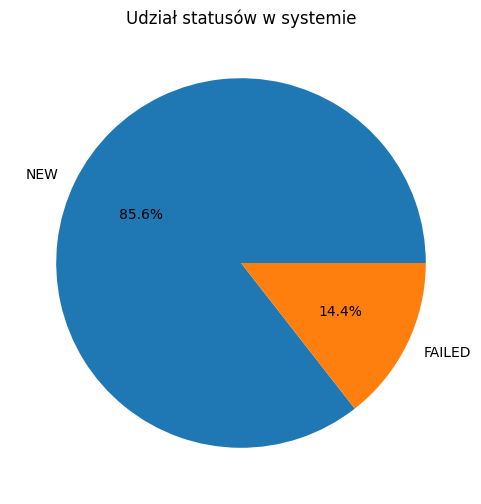

In [ ]:
#Wykres udziału statusów
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.pie(
    status_counts["count"],
    labels=status_counts["status"],
    autopct="%1.1f%%"
)
plt.title("Udział statusów w systemie")
plt.show()


In [ ]:
#Procentowy rozkład statusów per model
model_stats = (
    df.groupby(["model_group", "status"])
    .size()
    .unstack(fill_value=0)
)

model_stats["TOTAL"] = model_stats.sum(axis=1)

# Jeśli któryś status nie istnieje w danym modelu
if "FAILED" not in model_stats.columns:
    model_stats["FAILED"] = 0
if "NEW" not in model_stats.columns:
    model_stats["NEW"] = 0

# Procentowy rozkład dla statusu FAILED
model_stats["FAILED_%"] = (
    model_stats["FAILED"] / model_stats["TOTAL"] * 100
)

model_stats = model_stats.sort_values("TOTAL", ascending=False)

print(model_stats)


status              FAILED    NEW  TOTAL    FAILED_%
model_group                                         
GRAIN                  955  14453  15408    6.198079
INCLUSIONS            1649   1599   3248   50.769704
RETAINED_AUSTENITE     276   2951   3227    8.552835
CARBIDES               262   2771   3033    8.638312
DECARBURIZATION        198   2318   2516    7.869634
OXIDATION              778   1638   2416   32.201987
CUSTOM                 540   1835   2375   22.736842
LAYER                  363   1711   2074   17.502411
NITRIDE                171   1009   1180   14.491525
DENDRITES              145    984   1129   12.843224
RESIN                   94    829    923   10.184182
FERRITE                 47    771    818    5.745721
PEARLITE               134    565    699   19.170243
CRIMP                  104    193    297   35.016835
EXTRACT                 24    248    272    8.823529
CRACKS                  49    211    260   18.846154
MARTENSITE               9    208    217    4.

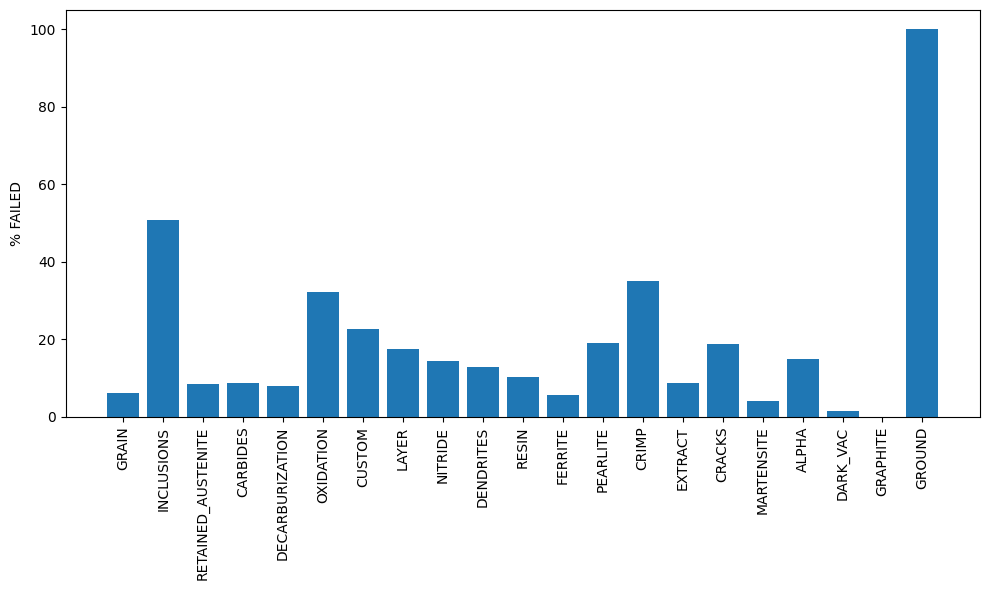

In [ ]:
#Wykresy procentowy failed per model
plt.figure(figsize=(10,6))
plt.bar(
    model_stats.index.astype(str),
    model_stats["FAILED_%"]
)

plt.xticks(rotation=90)
plt.ylabel("% FAILED")
plt.tight_layout()
plt.show()


In [ ]:
# Czy statusy failed zależą od rozmiaru obrazu
comparison = (
    df.groupby("status")[["pixel_count", "size"]]
    .agg(["mean", "median"])
)

print(comparison)

         pixel_count                     size           
                mean     median          mean     median
status                                                  
FAILED  5.063431e+06  3000000.0  7.039412e+06  2074436.0
NEW     3.989858e+06  3000000.0  6.213654e+06  3368149.0


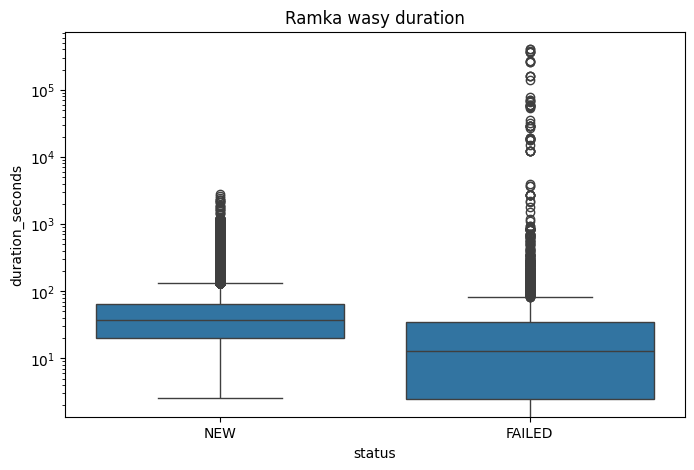

In [ ]:
#Rozkład dla pixel_count
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="status", y="duration_seconds")
plt.title("Ramka wasy duration")
plt.yscale("log")
plt.show()


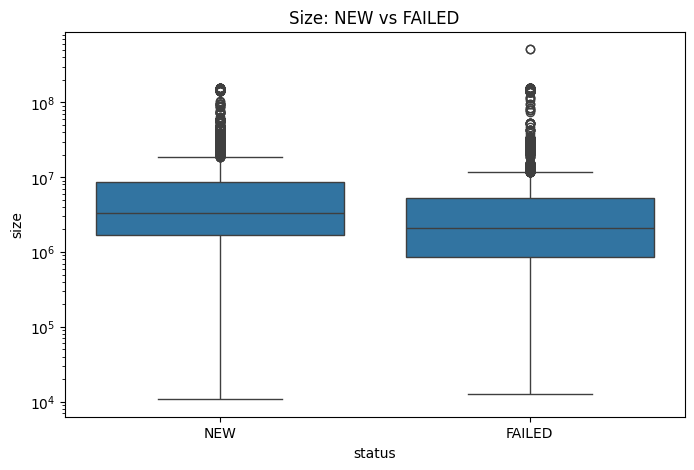

In [ ]:
#Rozkład dla size
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="status", y="size")
plt.title("Size: NEW vs FAILED")
plt.yscale("log")
plt.show()


In [ ]:
#Awaryjność niektórych zadań NIE ZALEŻY od rozmiarów czy wymiarów obrazów

In [ ]:
#Ściąga do pracy może?
#Analiza porównawcza rozkładów liczby pikseli oraz rozmiaru pliku dla zadań zakończonych sukcesem i niepowodzeniem
#nie wykazała istotnych różnic. Oznacza to, że awaryjność systemu nie jest bezpośrednio związana z wielkością przetwarzanego obrazu.

In [ ]:
#Obliczenie awaryjności per dzień
df_time_analysis = df.copy()
# Wyciągnięcie samej daty (bez godziny)
df_time_analysis["date"] = df_time_analysis["createdAtDate"].dt.date

# Agregacja per dzień
daily_stats = (
    df_time_analysis.groupby(["date", "status"])
    .size()
    .unstack(fill_value=0)
)

daily_stats["TOTAL"] = daily_stats.sum(axis=1)

if "FAILED" not in daily_stats.columns:
    daily_stats["FAILED"] = 0

daily_stats["FAILED_%"] = (
    daily_stats["FAILED"] / daily_stats["TOTAL"] * 100
)

print(daily_stats)


status      FAILED  NEW  TOTAL   FAILED_%
date                                     
2025-06-03       5    8     13  38.461538
2025-06-04       5   12     17  29.411765
2025-06-05       0    6      6   0.000000
2025-06-06       0    1      1   0.000000
2025-06-08       1    7      8  12.500000
...            ...  ...    ...        ...
2026-03-13      24  525    549   4.371585
2026-03-14       0   92     92   0.000000
2026-03-15      40  135    175  22.857143
2026-03-16     320  554    874  36.613272
2026-03-17       0    1      1   0.000000

[238 rows x 4 columns]


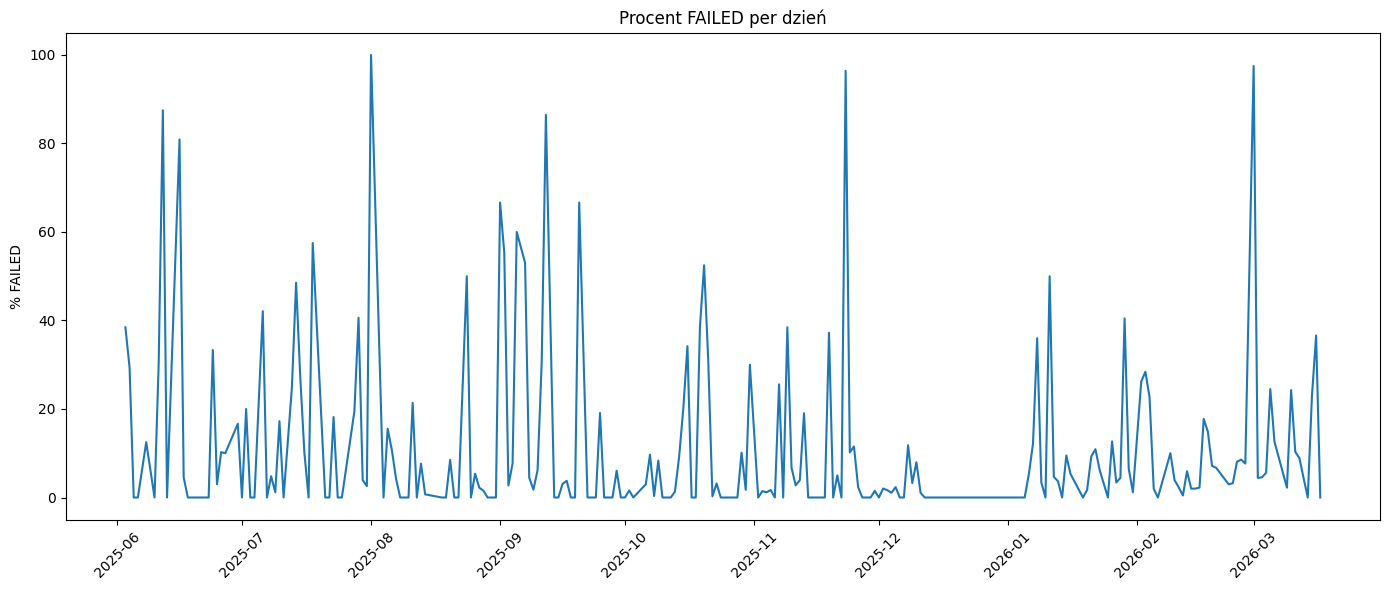

In [ ]:
#Wykres failed per dzień
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(daily_stats.index, daily_stats["FAILED_%"])
plt.xticks(rotation=45)
plt.ylabel("% FAILED")
plt.title("Procent FAILED per dzień")
plt.tight_layout()
plt.show()


In [ ]:
#W powyższym przypadku może dojść do sytuacji, w której w ciągu dnia będą wykonane tylko 3 taski z czego 2 z nich będą miały status FAILED. Branie ich pod uwagę na równi z dniami w których
#było już kilkaset tasków jest niepoprawne statystycznie. Z tego powodu odfiltrowano tylko takie dni, w których wykonano tylko powyżej 100 tasków

In [ ]:
daily_stats_filtered = daily_stats[daily_stats["TOTAL"] > 100]


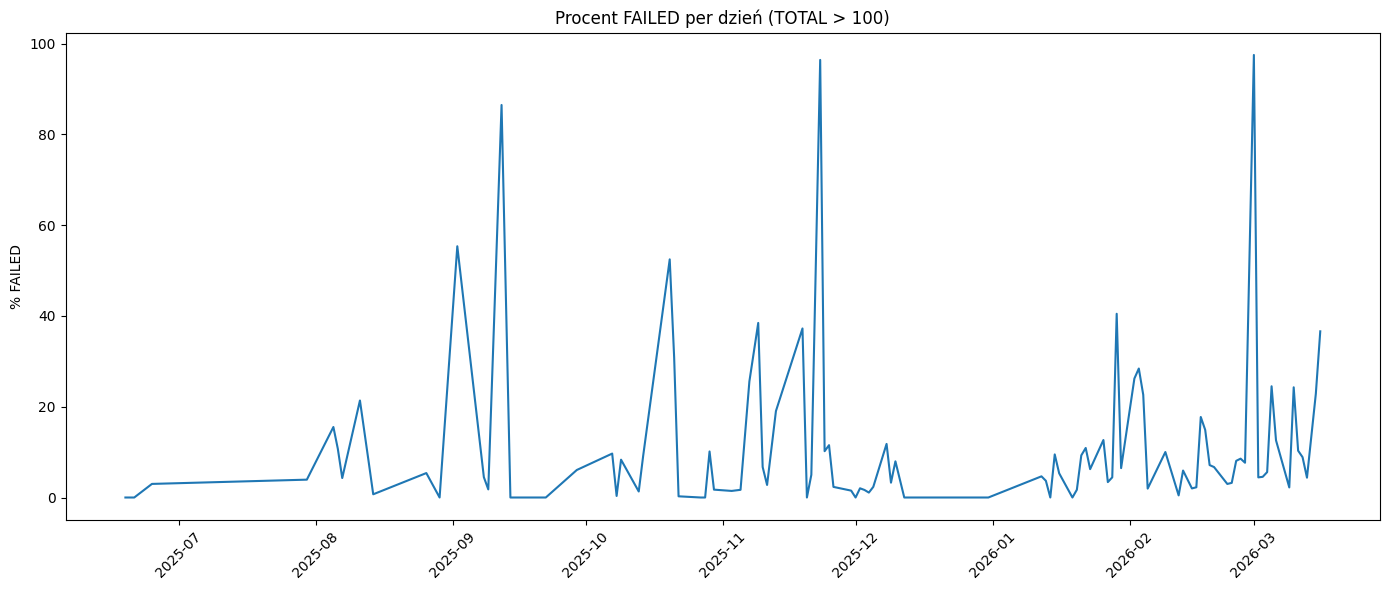

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(daily_stats_filtered.index, daily_stats_filtered["FAILED_%"])
plt.xticks(rotation=45)
plt.ylabel("% FAILED")
plt.title("Procent FAILED per dzień (TOTAL > 100)")
plt.tight_layout()
plt.show()


In [ ]:
#Jak widać w tym przypadku skoki w większym udziale zadań o statusie FAILED pojawiają się rzadziej

In [ ]:
# Awaryjność per godzina
df_time_analysis["hour"] = df_time_analysis["createdAtDate"].dt.hour

hourly_stats = (
    df_time_analysis.groupby(["hour", "status"])
    .size()
    .unstack(fill_value=0)
)

hourly_stats["TOTAL"] = hourly_stats.sum(axis=1)

if "FAILED" not in hourly_stats.columns:
    hourly_stats["FAILED"] = 0

hourly_stats["FAILED_%"] = (
    hourly_stats["FAILED"] / hourly_stats["TOTAL"] * 100
)

print(hourly_stats)


status  FAILED   NEW  TOTAL   FAILED_%
hour                                  
0          220   343    563  39.076377
1            0    56     56   0.000000
2          196    57    253  77.470356
3            1    35     36   2.777778
4            1    58     59   1.694915
5          150   747    897  16.722408
6          175  1804   1979   8.842850
7          292  2798   3090   9.449838
8          480  2870   3350  14.328358
9          351  3022   3373  10.406167
10         551  3400   3951  13.945836
11         229  2186   2415   9.482402
12         420  3333   3753  11.191047
13         343  2098   2441  14.051618
14         411  1859   2270  18.105727
15          82   993   1075   7.627907
16          95  1235   1330   7.142857
17          89  1784   1873   4.751735
18          13   382    395   3.291139
19        1168   683   1851  63.101026
20          90  1186   1276   7.053292
21         177  1565   1742  10.160735
22         129  1137   1266  10.189573
23         152   806    9

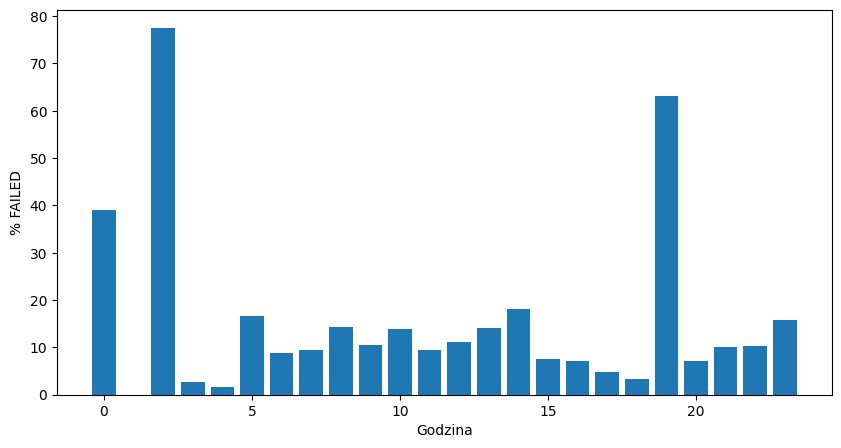

In [ ]:
#Wykres per godzina
plt.figure(figsize=(10,5))
plt.bar(hourly_stats.index, hourly_stats["FAILED_%"])
plt.xlabel("Godzina")
plt.ylabel("% FAILED")
plt.show()


In [ ]:
hourly_stats.sort_values("TOTAL", ascending=False)


status,FAILED,NEW,TOTAL,FAILED_%
hour,,,,
10,551,3400,3951,13.945836
12,420,3333,3753,11.191047
9,351,3022,3373,10.406167
8,480,2870,3350,14.328358
7,292,2798,3090,9.449838
13,343,2098,2441,14.051618
11,229,2186,2415,9.482402
14,411,1859,2270,18.105727
6,175,1804,1979,8.842850


In [ ]:
#Wstępny wniosek
# Awaryjność NIE zależy od rozmiaru obrazu
# Awaryjność zależy silnie od modelu
# Zależy od godziny
# Występują niektóre dni z podwyższoną awaryjnością

In [ ]:
#Niemniej jednak trudno w pracy będzie zaimplementować symulacji w oparciu o czas systemowy, nie mówiąc już o tym, że mogło dojść do sytuacji, gdzie o godzinie 13 akurat uruchamiano modele,
#które charakteryzują się największą awaryjnością

#Z tego względu modelowania oprzemy najprawdopodobniej na aproksymacji P(FAILED | modelId)

In [ ]:
#------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [ ]:
#Etap 3 - Analiza czasu wykonania dla zadań o statusie NEW

In [ ]:
#Filtrowanie rekordów o statusie NEW
df_new = df[df["status"] == "NEW"].copy()

print("Liczba rekordów NEW:", len(df_new))


Liczba rekordów NEW: 34437


In [ ]:
#usuwanie rekordów z błędnymi datami
df_new = df_new.dropna(subset=["startedAtDate", "finishedAtDate"])

print("Po usunięciu błędnych dat:", len(df_new))


Po usunięciu błędnych dat: 34437


In [ ]:
#duration w milisekundach
df_new["duration_ms"] = (
    df_new["duration_seconds"] * 1000
    + df_new["finishedAtMiliseconds"].astype(float)
    - df_new["startedAtMiliseconds"].astype(float)
)


In [ ]:
#usunięcie rekordów w których duration jest mniejsze od zera
df_new = df_new[df_new["duration_ms"] > 0]

print("Po filtrze duration > 0:", len(df_new))


Po filtrze duration > 0: 34437


In [ ]:
#Statystyka dla przygotowanych danych o statusie NEW
df_new["duration_seconds"].describe(percentiles=[0.9, 0.95, 0.99])


,duration_seconds
count,34437.000000
mean,64.401818
std,111.994129
min,2.540000
50%,36.649000
90%,124.231800
95%,193.755000
99%,558.579560
max,2791.267000


In [ ]:
#ile zadań trwa więcej niż 1000 s
(df_new["duration_seconds"] > 1000).mean() * 100


np.float64(0.5197897610128641)

In [ ]:
#ile zadań trwa mniej niż 5s
(df_new["duration_seconds"] < 5).mean() * 100

np.float64(0.043557801202195316)

In [ ]:
#0.52% to procentowa ilość zadań, które trwają więcej niż 1000 sekund - są to wartości małe i bardzo odstające
#0.04% to procentowa ilość zadań, które trwają mniej niż 5 sekund - są to wartość również małe, niemniej jednak możliwe do uzyskania ze względu na ilość występujących rekordów z takimi czasami


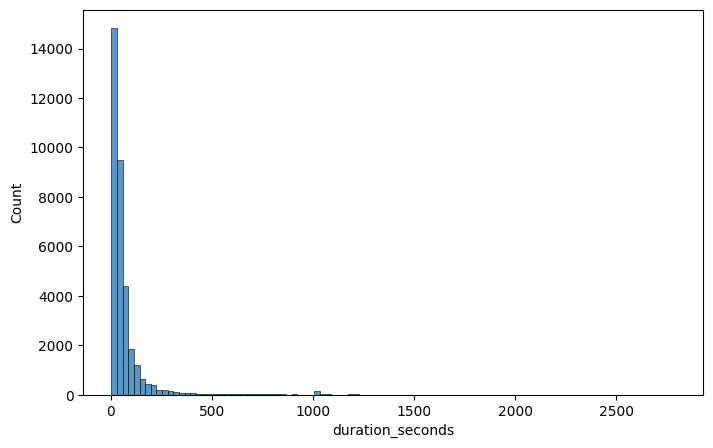

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df_new["duration_seconds"], bins=100)
plt.show()


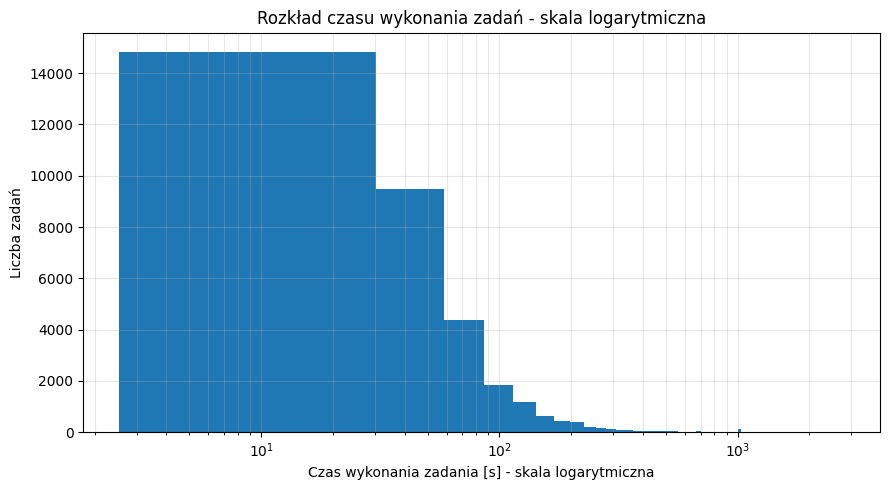

In [ ]:
import matplotlib.pyplot as plt

# Bierzemy tylko poprawne, dodatnie czasy wykonania
duration = df_new["duration_seconds"].dropna()
duration = duration[duration > 0]

plt.figure(figsize=(9, 5))

plt.hist(duration, bins=100)

plt.xscale("log")

plt.title("Rozkład czasu wykonania zadań - skala logarytmiczna")
plt.xlabel("Czas wykonania zadania [s] - skala logarytmiczna")
plt.ylabel("Liczba zadań")

plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
#zapisujemy 99% danych
p99 = df_new["duration_seconds"].quantile(0.99)
print("P99:", p99)


P99: 558.5795599999999


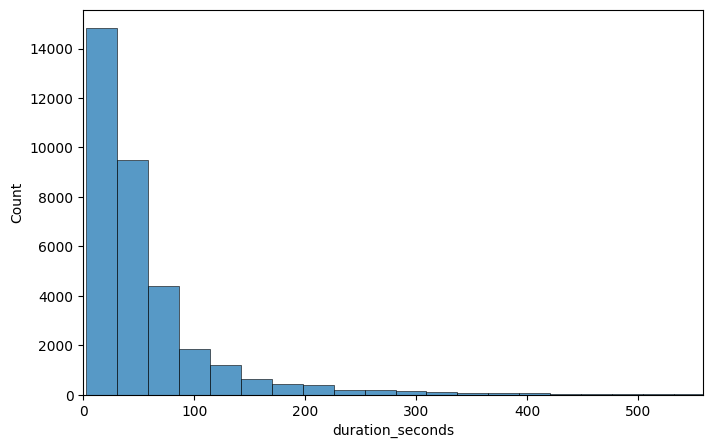

In [ ]:
#Histogram dla pierwszych 99% danych (bez ogona)
plt.figure(figsize=(8,5))

sns.histplot(df_new["duration_seconds"], bins=100)

plt.xlim(0, p99)
plt.show()


In [ ]:
#Mediana dla poszczególnych modeli
df_new.groupby("modelId")["duration_seconds"].median().sort_values(ascending=False)


,duration_seconds
modelId,
e2bce0f8-15b8-4b42-bbc0-85c5e126ca2c,166.8905
888db13b-1ecb-4076-97c9-f8fa5e810ee0,139.5215
962f5b7a-6059-47c2-b4b0-9a9af9f6499e,133.6640
bfa75e35-a5fe-45e4-b2a1-6d7219ee4346,131.1750
688b2c93-2895-4107-afe9-ff6a6599af11,108.1570
...,...
0fa79e4e-2937-45f2-b5db-32bf7626ba66,15.0000
08e31aa6-36a4-4833-9479-a849d75f1ba0,14.9450
38b2b011-9e88-4355-acc9-af7bbc8ae6ba,14.1390


In [ ]:
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [ ]:
#ETAP 4 - Analiza czasu per model


In [ ]:
#Podstawowa statystyka per
model_stats = (
    df_new
    .groupby("model_group")["duration_seconds"]
    .agg([
        "count",
        "mean",
        "median",
        "std",
        "min",
        "max"
    ])
    .sort_values("median", ascending=False)
)

model_stats


,count,mean,median,std,min,max
model_group,,,,,,
GRAPHITE,14,289.187929,139.5215,301.715495,95.084,1080.140
CRIMP,193,122.650798,105.9730,48.872012,56.180,337.575
DECARBURIZATION,2318,102.007568,62.7090,123.809776,10.272,2246.915
FERRITE,771,94.288441,58.6870,132.977646,13.694,1153.902
PEARLITE,565,95.164550,53.4190,143.481181,14.063,1185.636
CARBIDES,2771,104.298214,53.0610,132.896783,6.204,1075.118
MARTENSITE,208,64.791173,45.0660,56.300098,13.067,367.401
ALPHA,68,66.894691,44.9890,89.164190,11.973,676.584
INCLUSIONS,1599,58.285979,44.9290,57.396452,17.171,1550.128


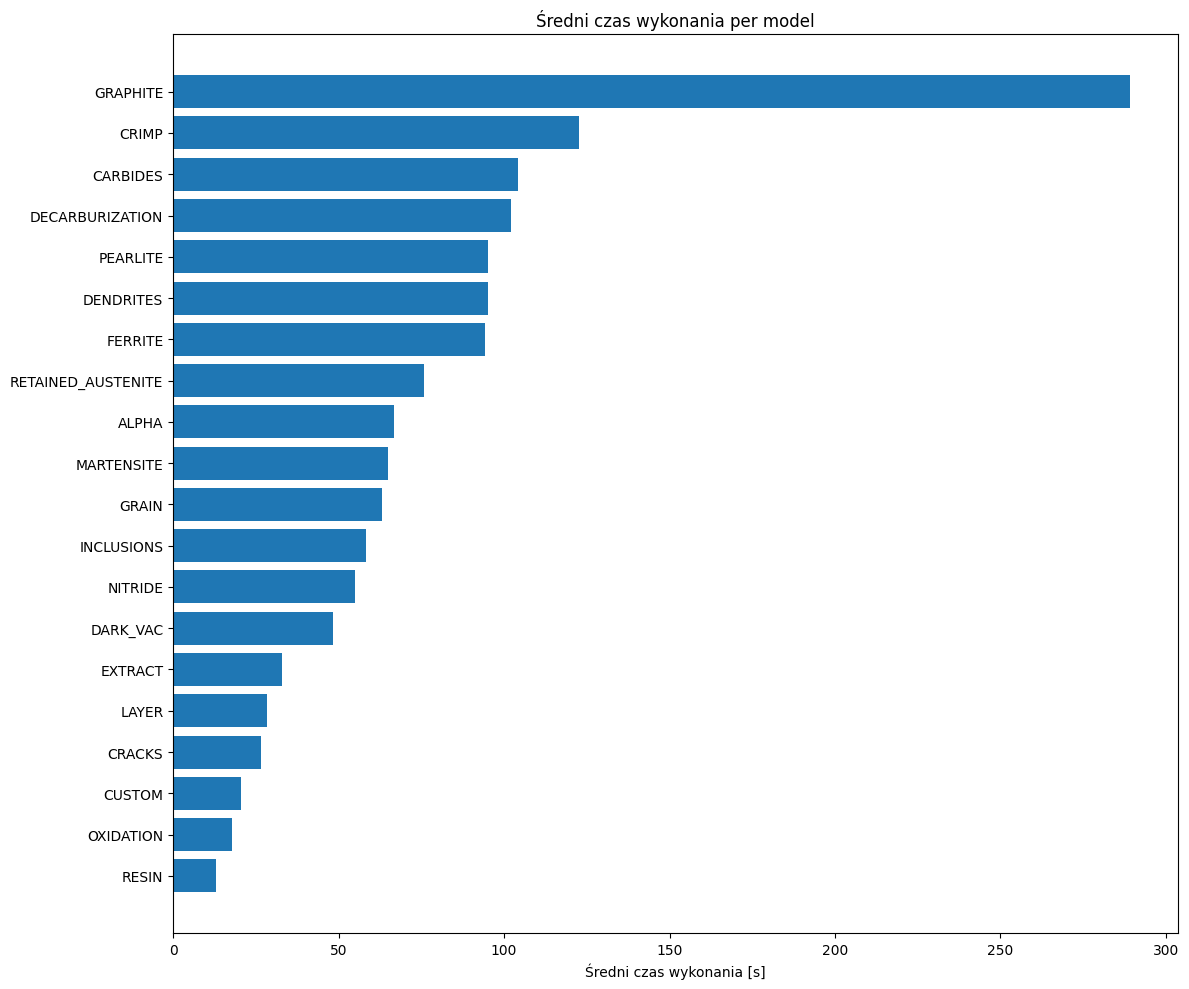

In [ ]:
model_stats_sorted_mean = model_stats.sort_values("mean")

plt.figure(figsize=(12,10))
plt.barh(
    model_stats_sorted_mean.index.astype(str),
    model_stats_sorted_mean["mean"]
)

plt.xlabel("Średni czas wykonania [s]")
plt.title("Średni czas wykonania per model")
plt.tight_layout()
plt.show()


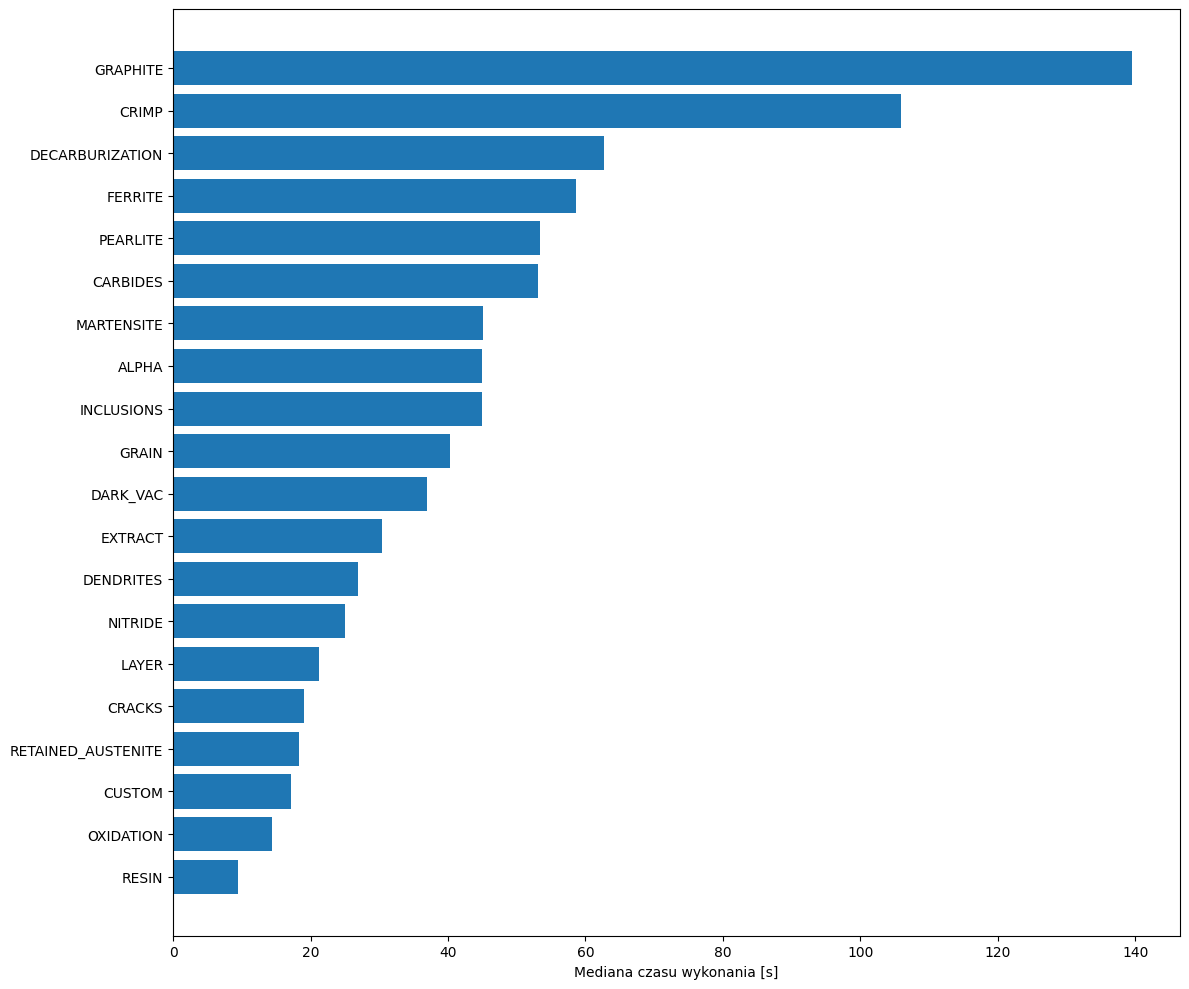

In [ ]:
#Mediana per model
model_stats_sorted_median = model_stats.sort_values("median")

plt.figure(figsize=(12,10))
plt.barh(
    model_stats_sorted_median.index.astype(str),
    model_stats_sorted_median["median"]
)

plt.xlabel("Mediana czasu wykonania [s]")
plt.tight_layout()
plt.show()


In [ ]:
#Korelacja duration vs pixel_count per model
corr_per_model_pixel = (
    df_new
    .groupby("model_group")[["duration_seconds", "pixel_count"]]
    .corr()
    .iloc[0::2, -1]
    .sort_values(ascending=False)
)

corr_per_model_pixel


,,pixel_count
model_group,,
INCLUSIONS,duration_seconds,0.932422
CRACKS,duration_seconds,0.878588
CARBIDES,duration_seconds,0.711943
DENDRITES,duration_seconds,0.658843
ALPHA,duration_seconds,0.648674
PEARLITE,duration_seconds,0.602078
CUSTOM,duration_seconds,0.468968
DARK_VAC,duration_seconds,0.464618
OXIDATION,duration_seconds,0.454409


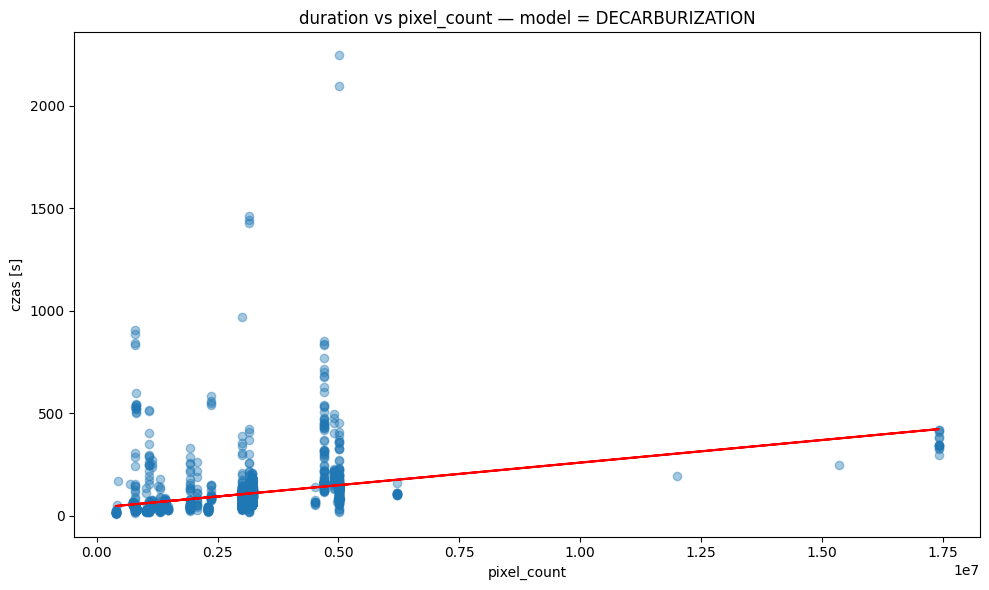

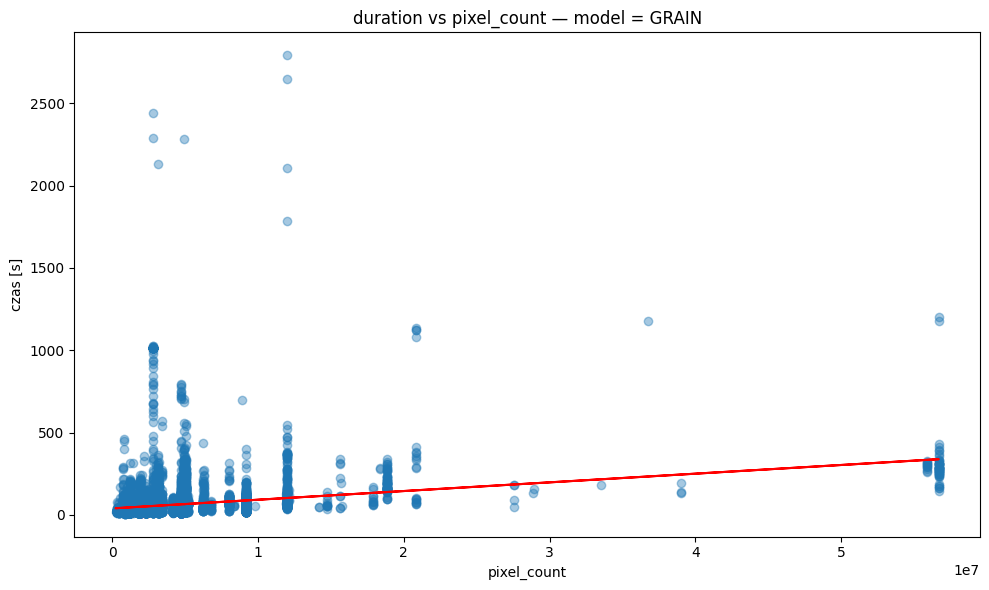

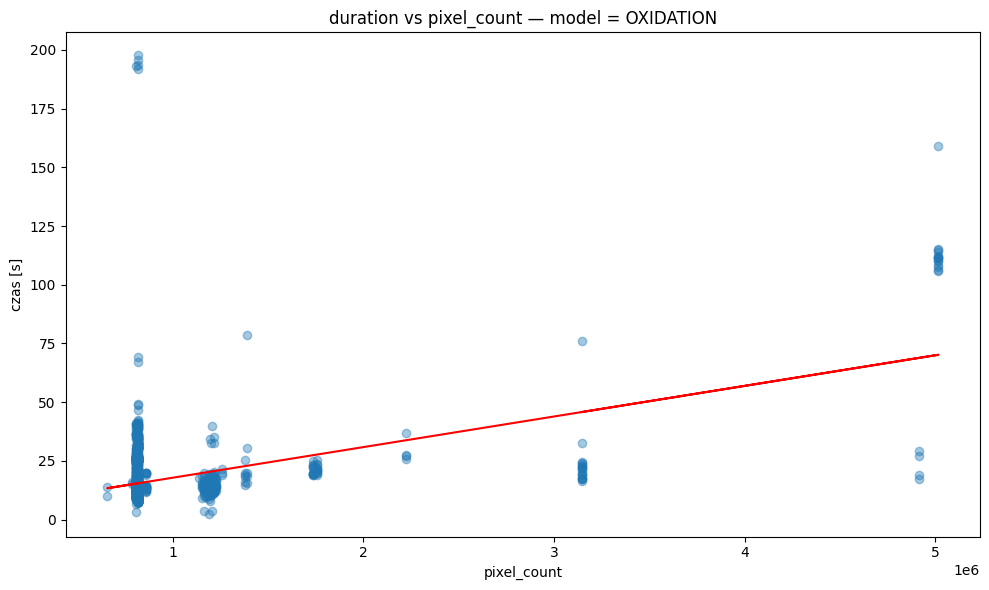

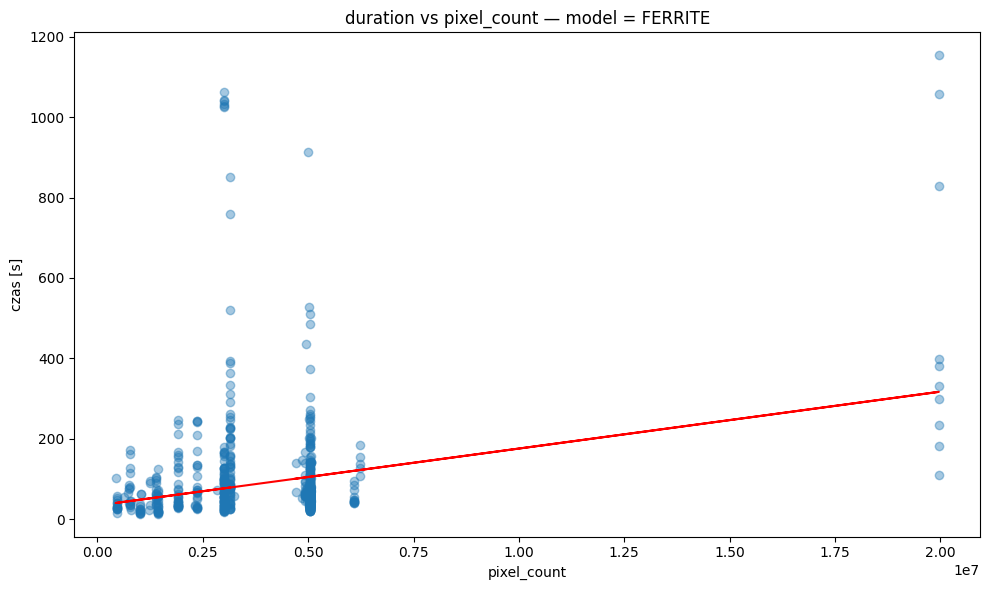

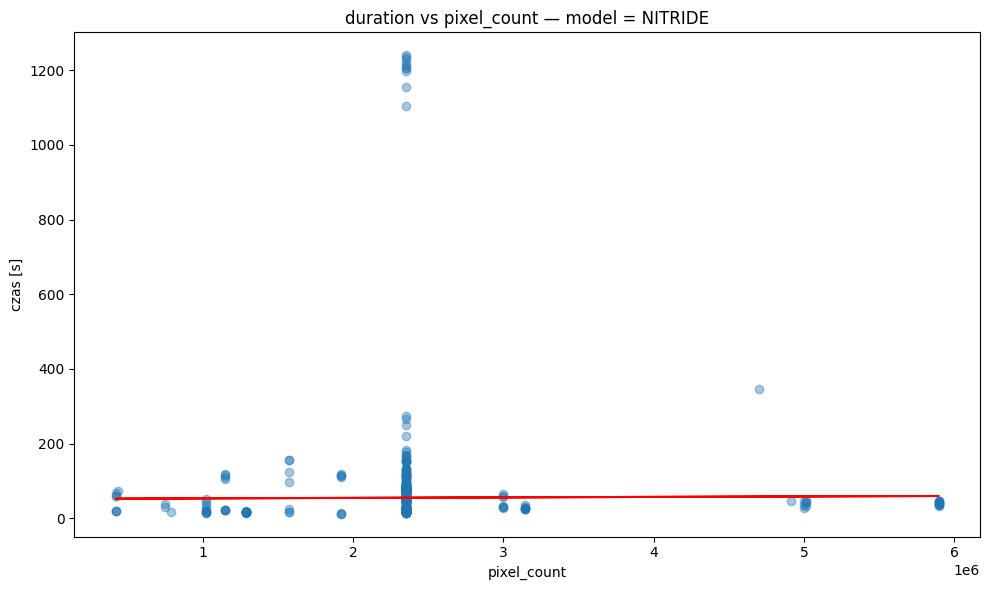

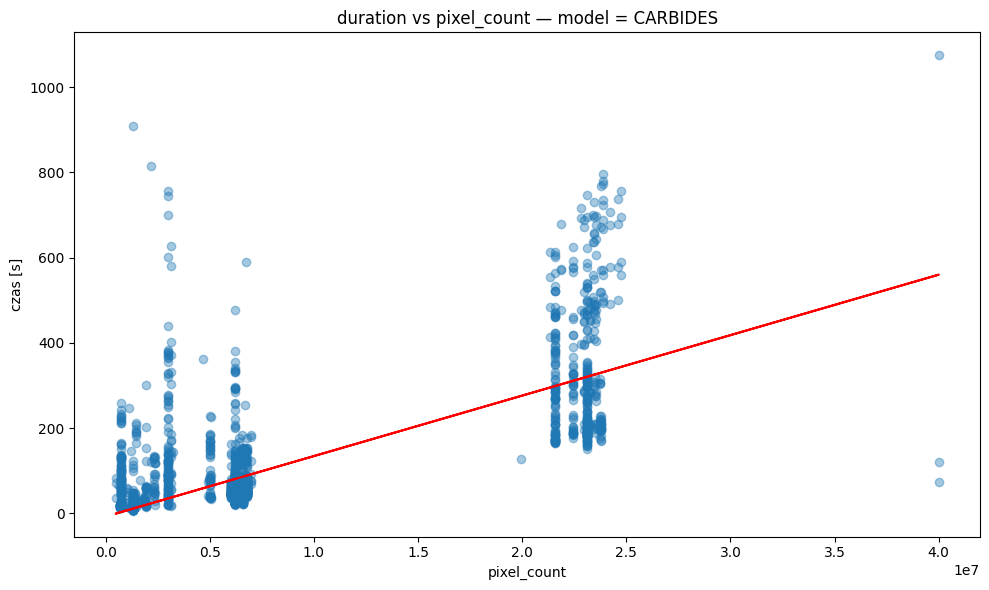

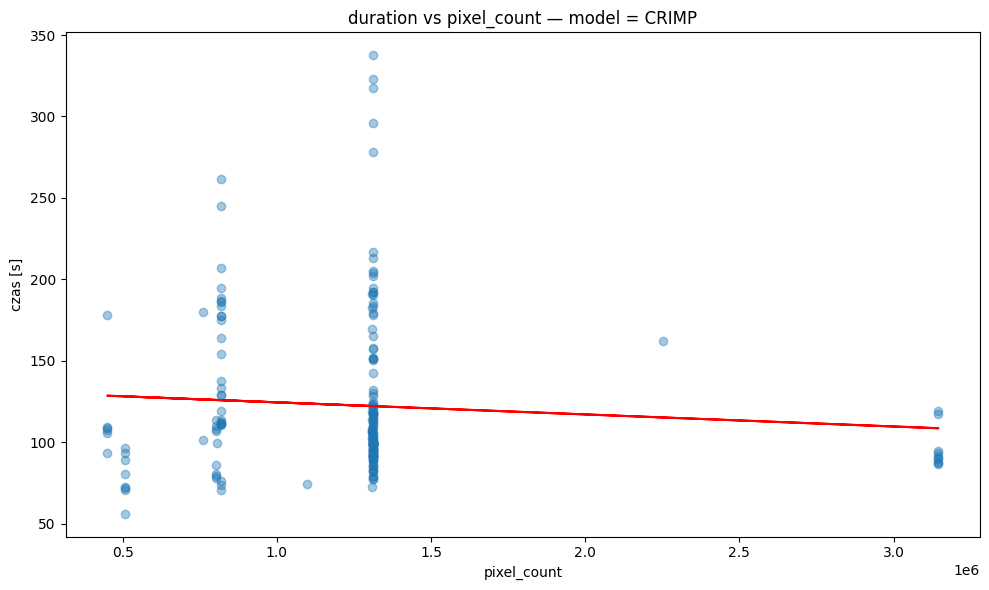

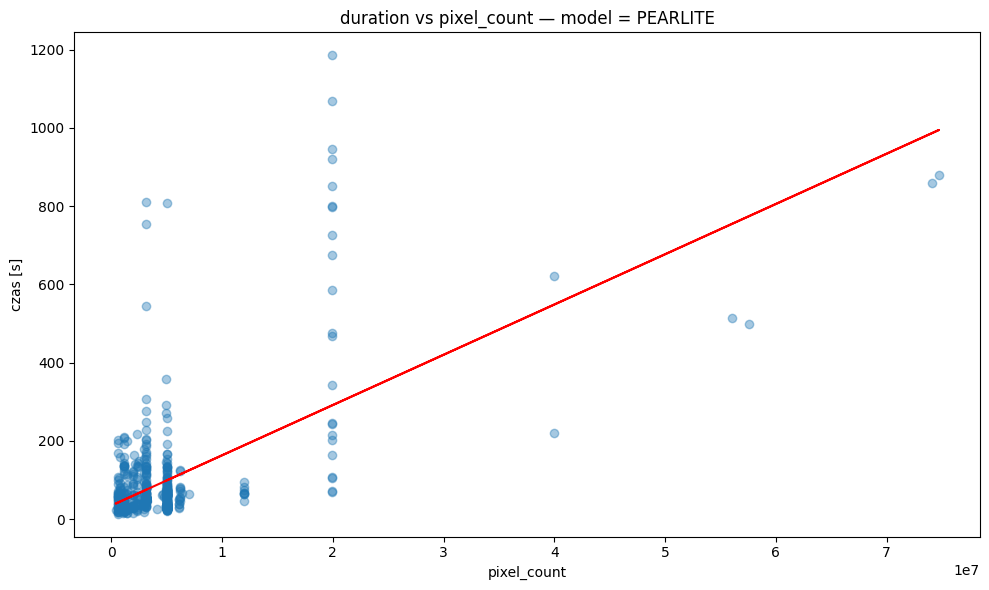

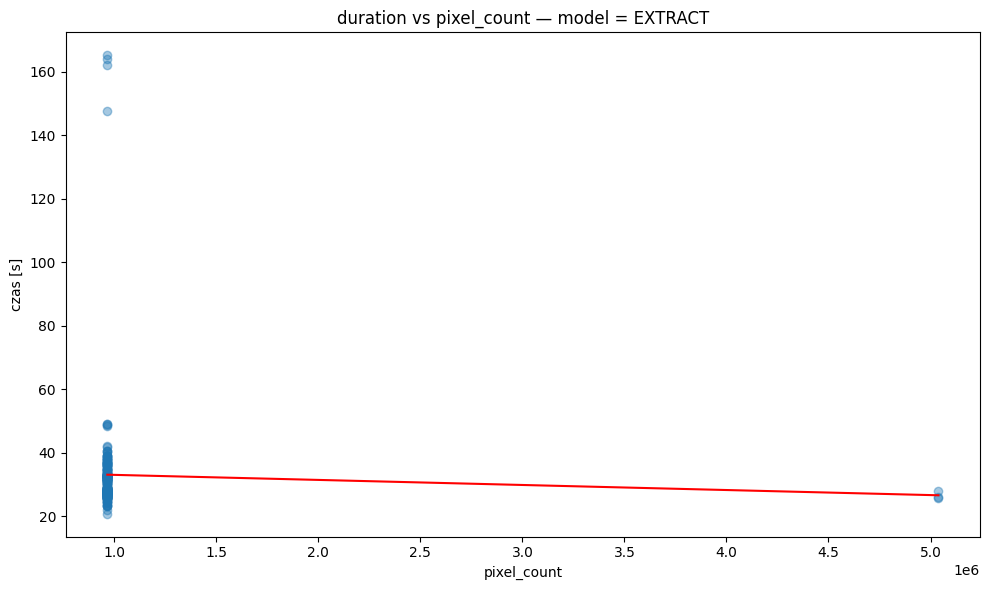

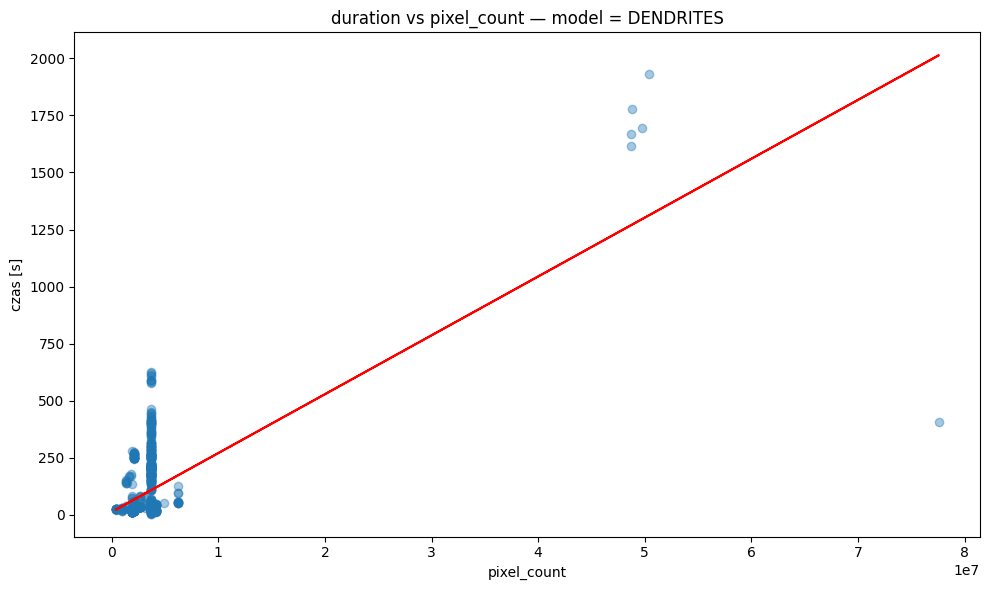

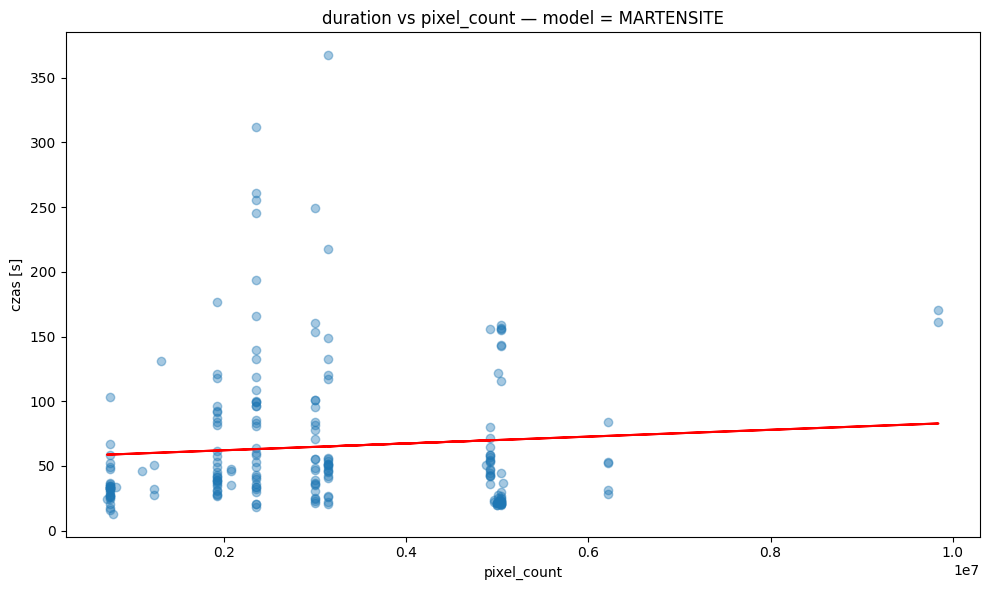

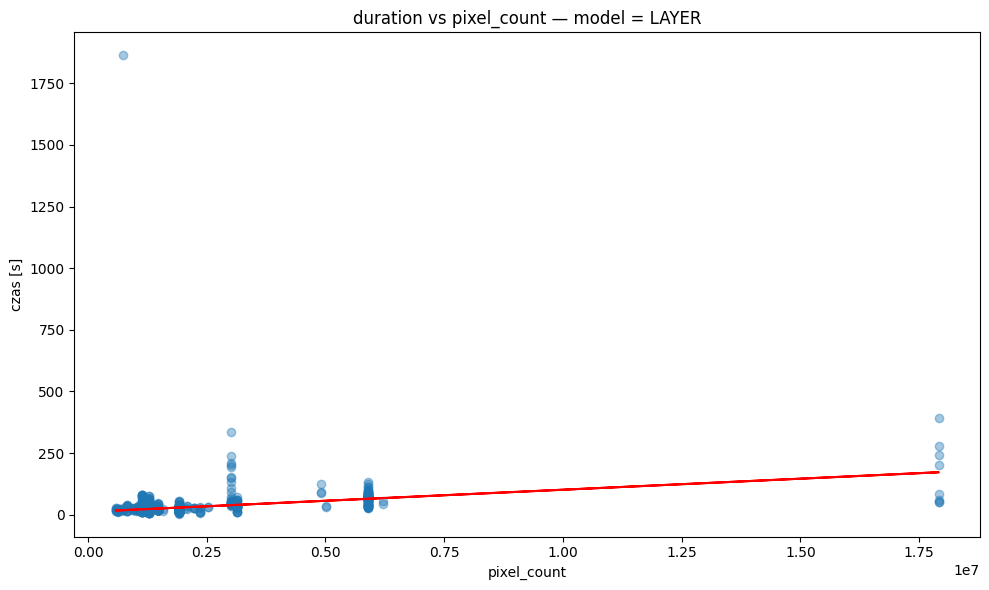

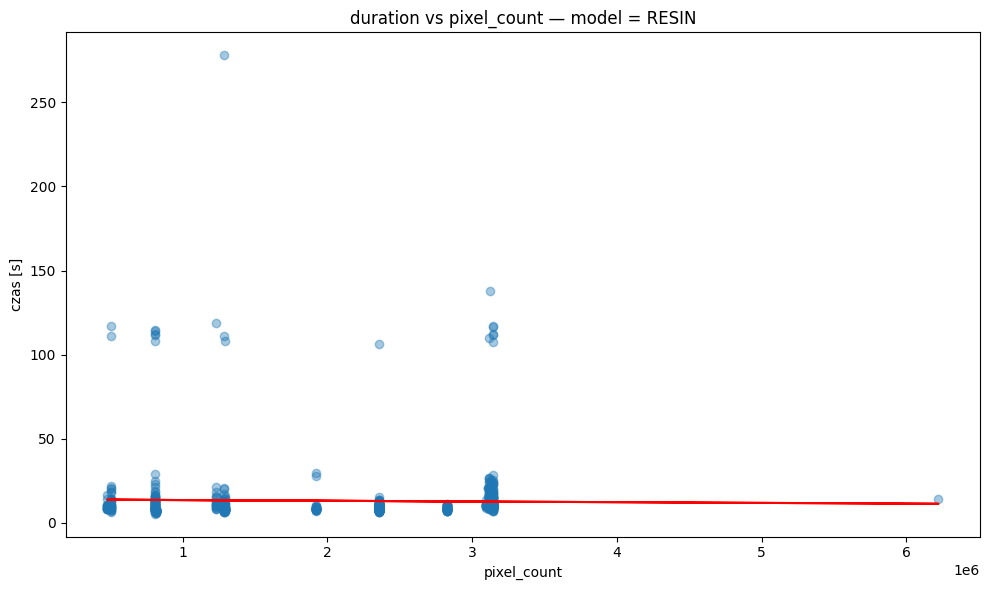

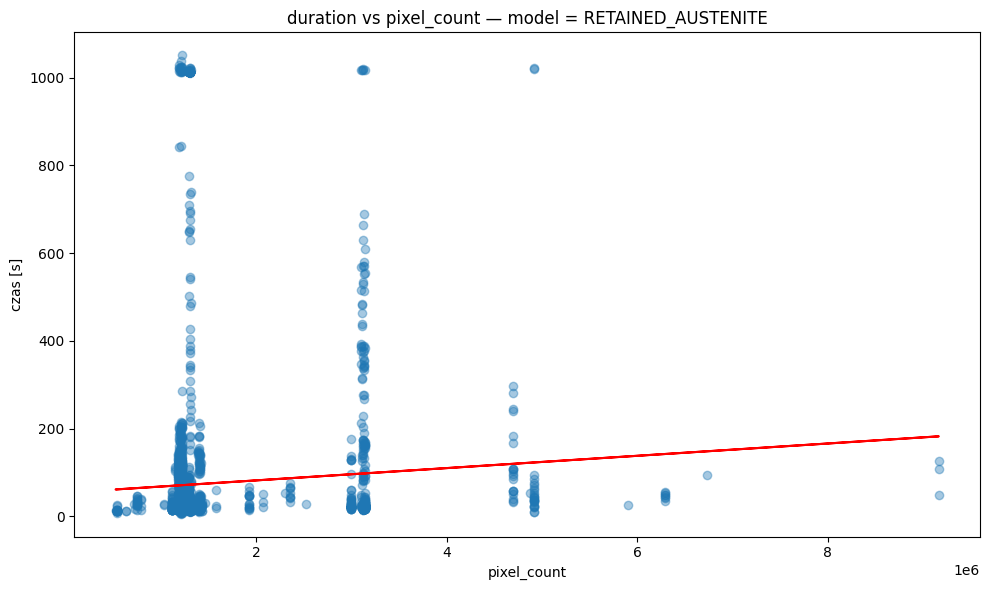

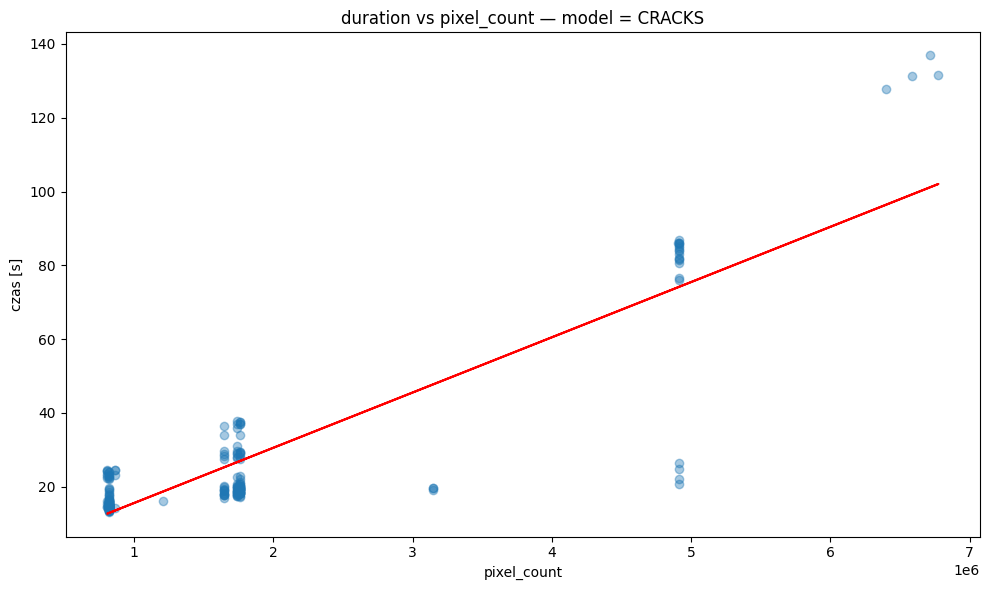

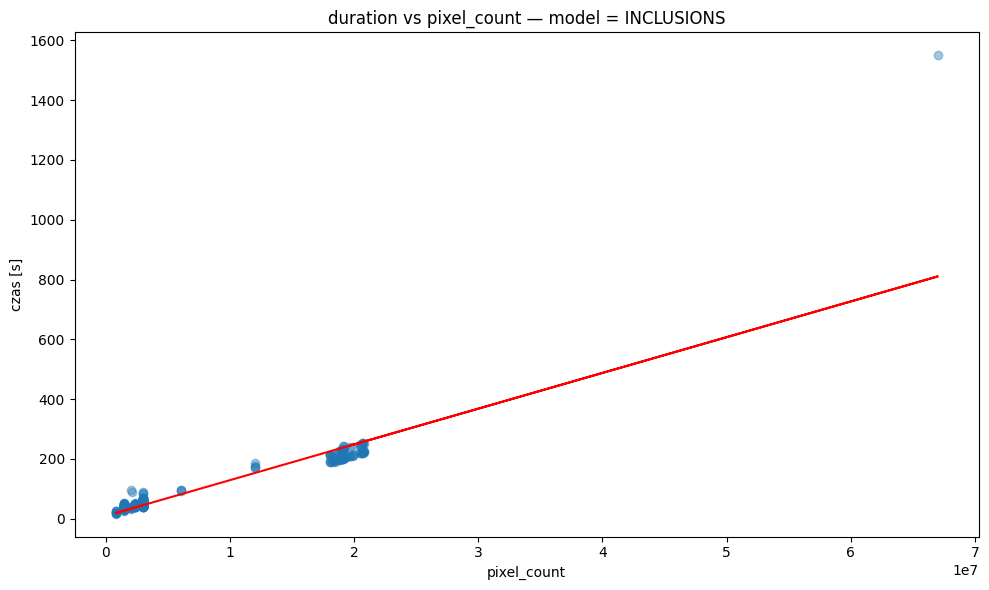

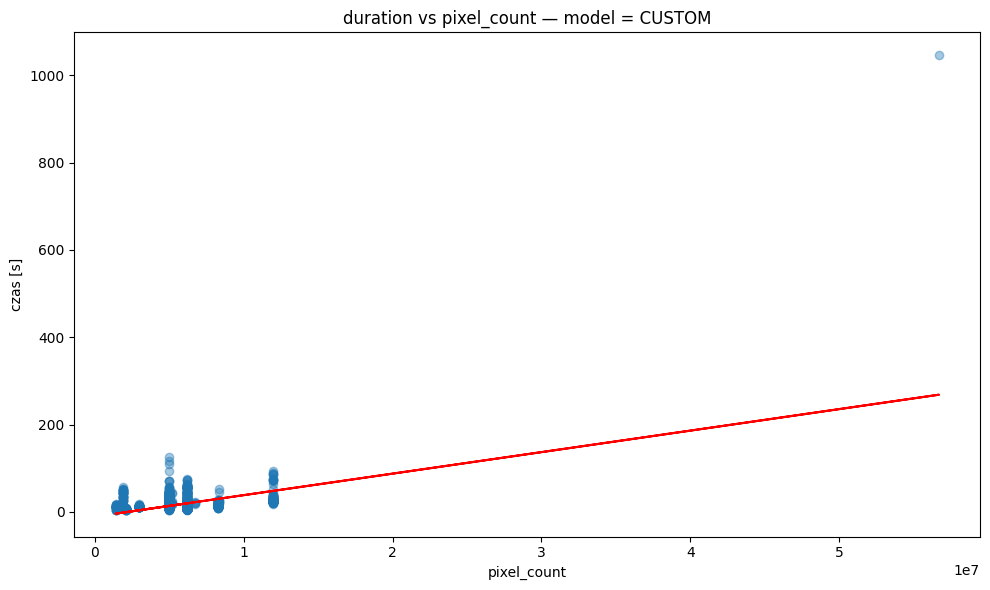

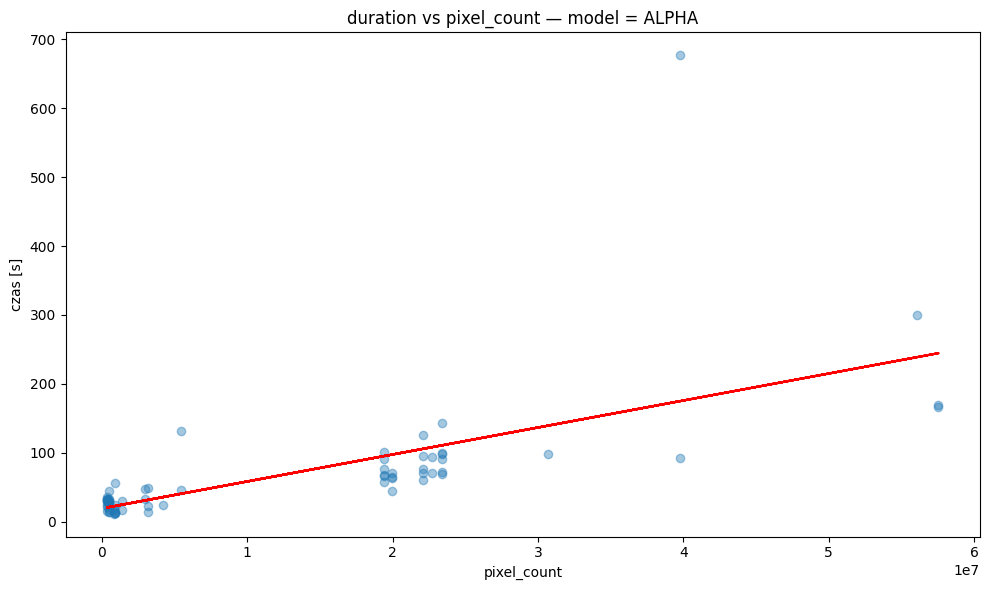

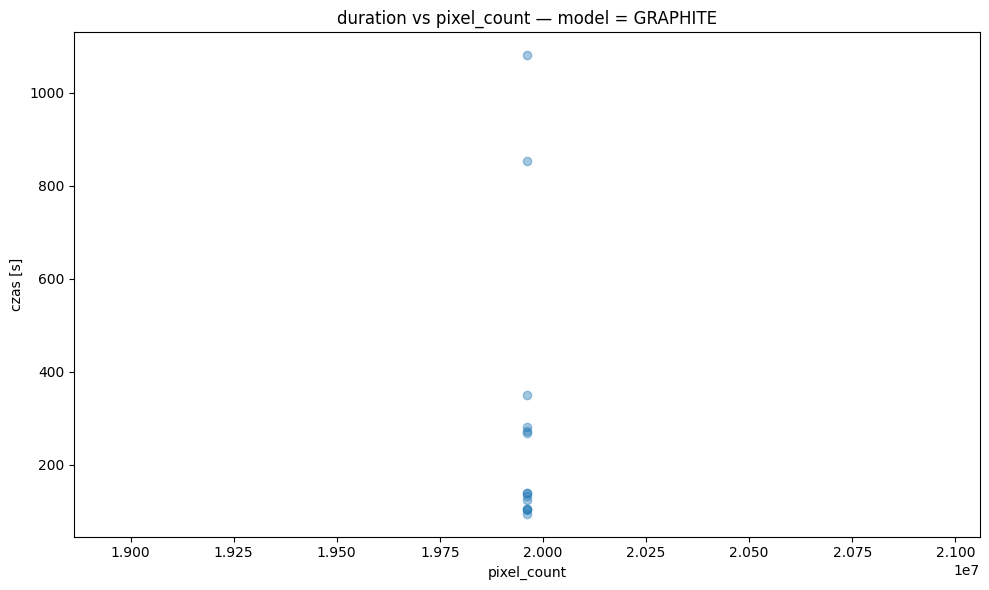

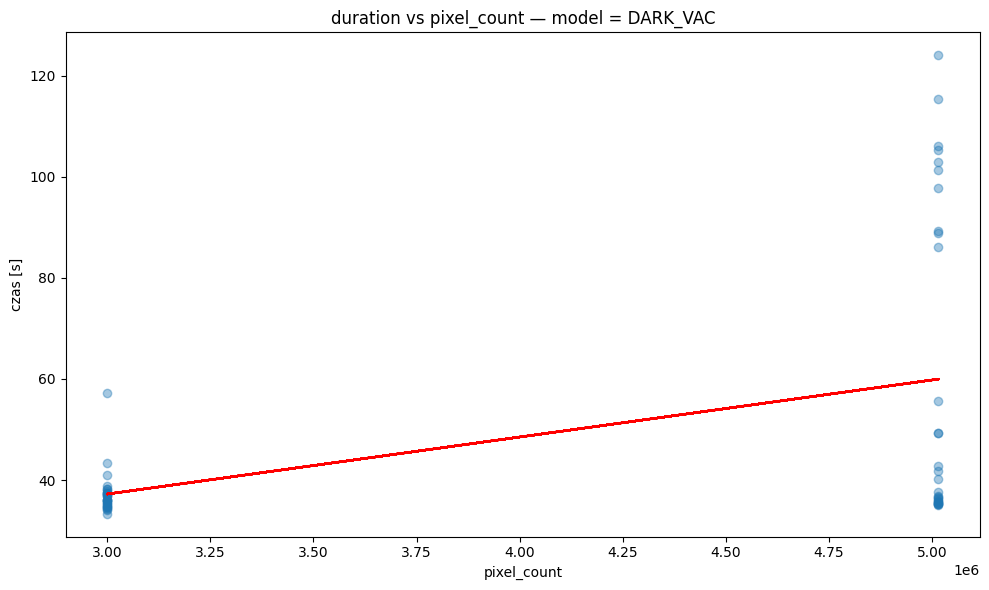

In [ ]:
#Wykresy duration vs pixel_count per model
models = df_new["model_group"].unique()

for m in models:
    subset = df_new[df_new["model_group"] == m][
        ["pixel_count", "duration_seconds"]
    ].dropna()

    plt.figure(figsize=(10,6))
    plt.scatter(subset["pixel_count"], subset["duration_seconds"], alpha=0.4)

    # sprawdzamy czy da się policzyć regresję
    if len(subset) > 2 and subset["pixel_count"].nunique() > 1:
        try:
            coef = np.polyfit(subset["pixel_count"], subset["duration_seconds"], 1)
            trend = coef[0] * subset["pixel_count"] + coef[1]
            plt.plot(subset["pixel_count"], trend, color="red")
        except:
            pass

    plt.title(f"duration vs pixel_count — model = {str(m)}")
    plt.xlabel("pixel_count")
    plt.ylabel("czas [s]")
    plt.tight_layout()
    plt.show()



In [ ]:
#Ucinamy odstające wartości żeby zobaczyć dokładniej wykresy
d_low = df_new["duration_seconds"].quantile(0.01)
d_high = df_new["duration_seconds"].quantile(0.99)

p_low = df_new["pixel_count"].quantile(0.01)
p_high = df_new["pixel_count"].quantile(0.99)

df_cut = df_new[
    (df_new["duration_seconds"] >= d_low) & (df_new["duration_seconds"] <= d_high) &
    (df_new["pixel_count"] >= p_low) & (df_new["pixel_count"] <= p_high)
].copy()

print("Przed:", len(df_new))
print("Po:", len(df_cut))


Przed: 34437
Po: 33241


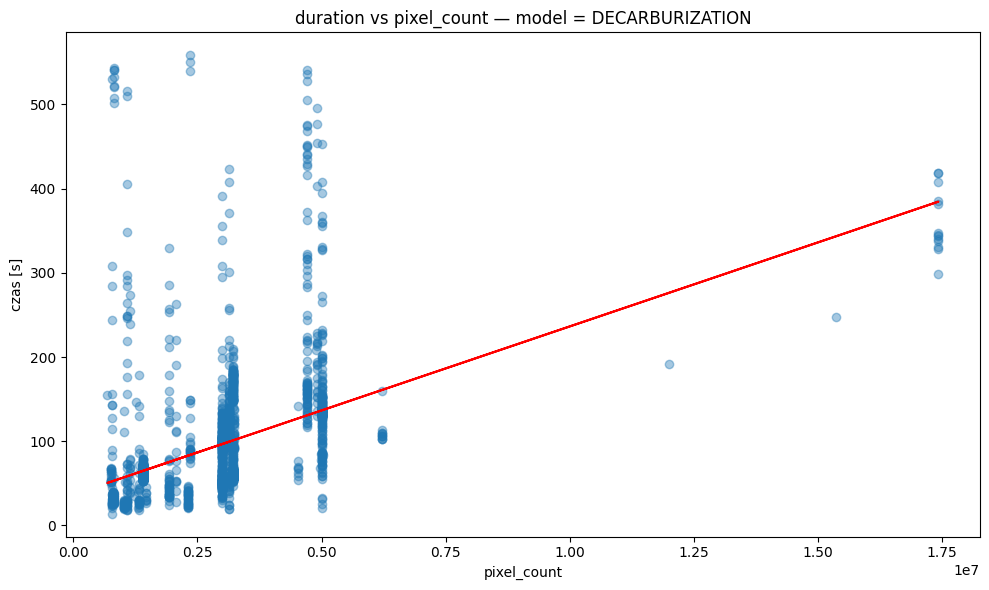

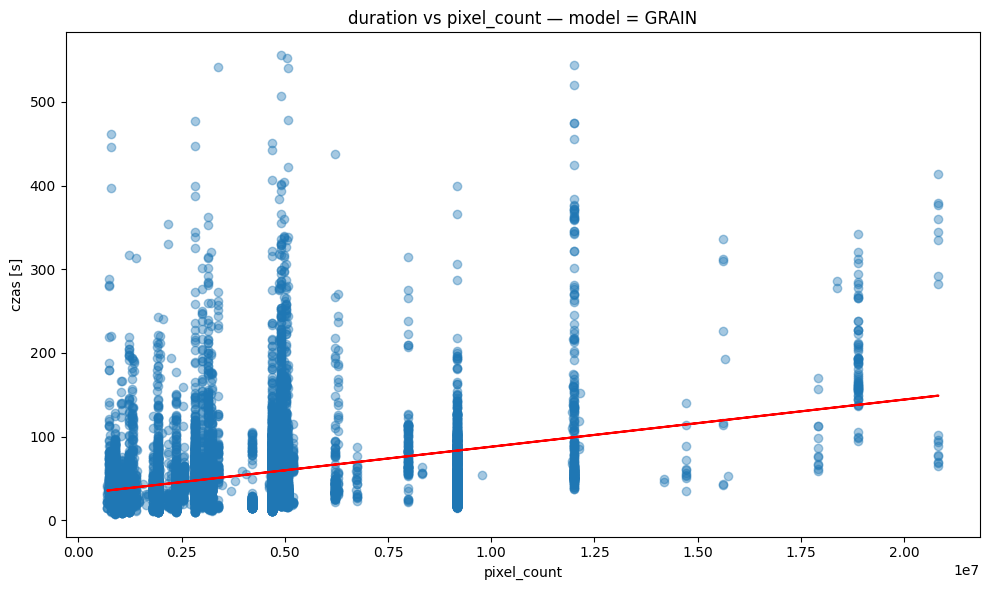

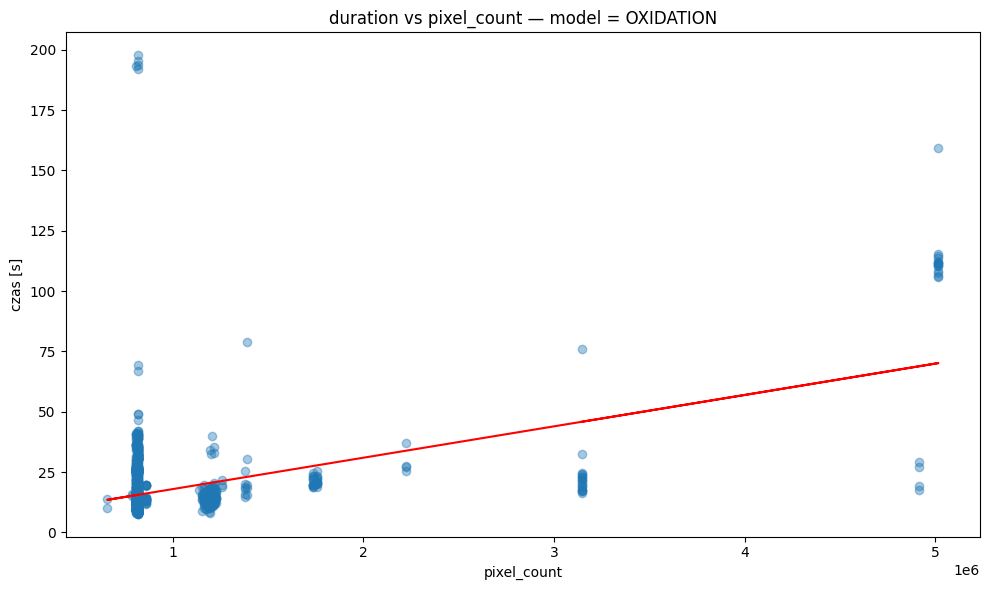

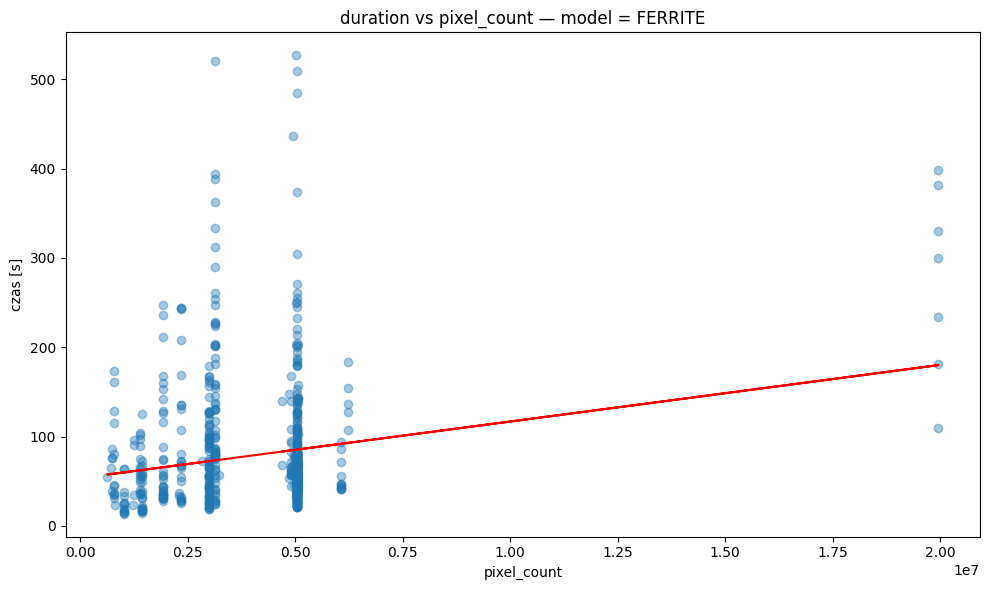

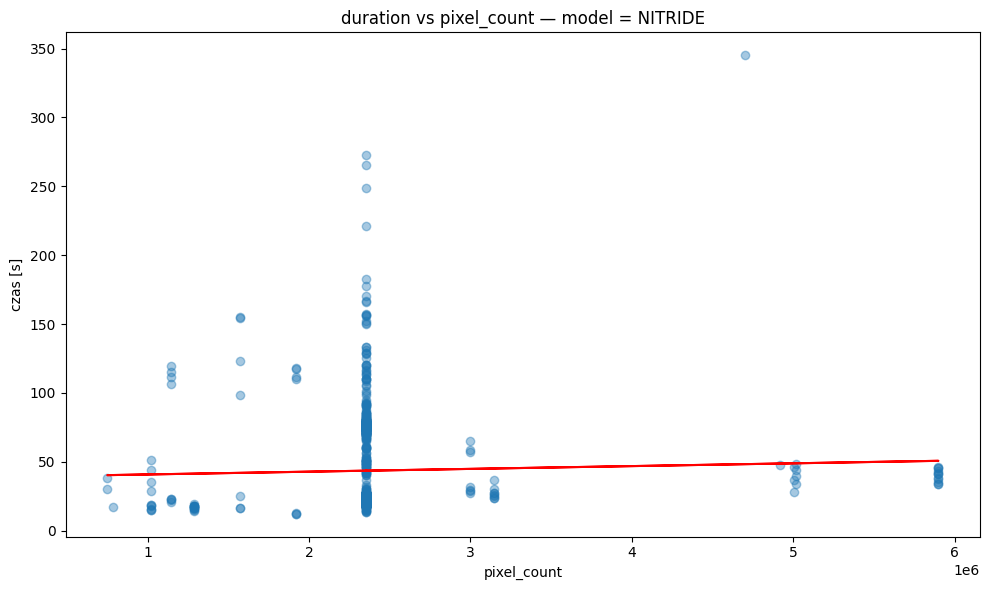

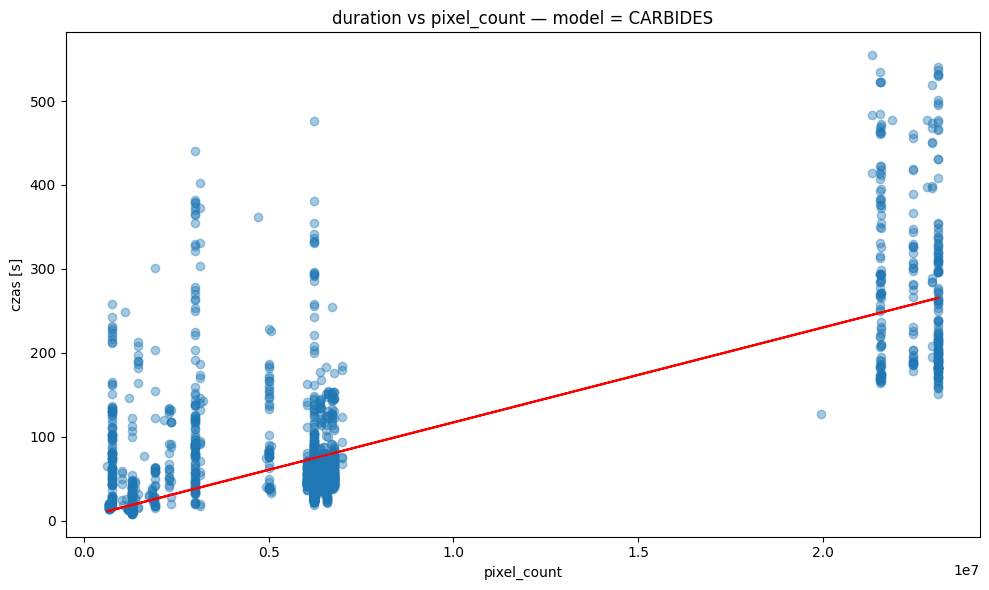

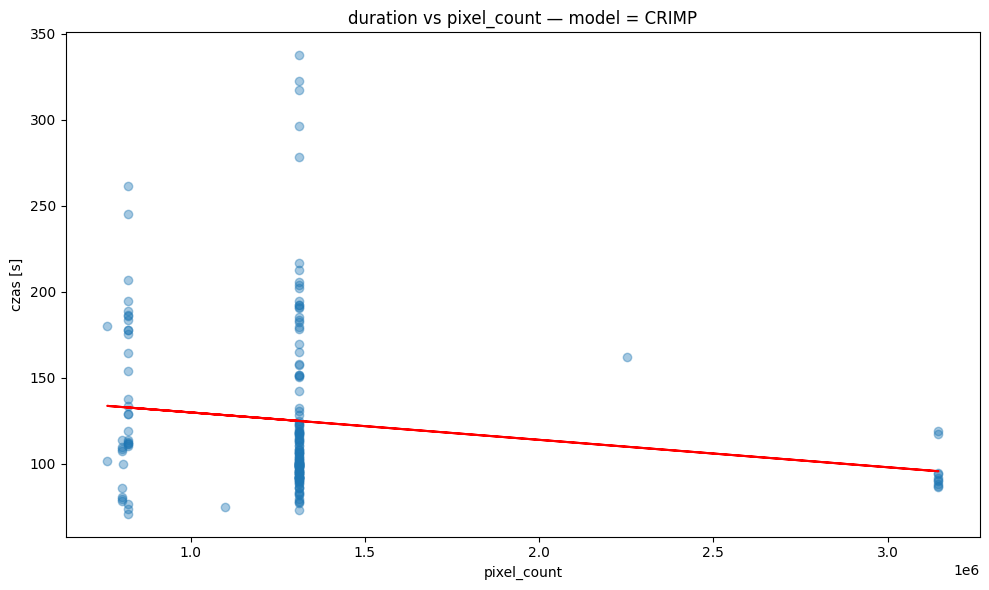

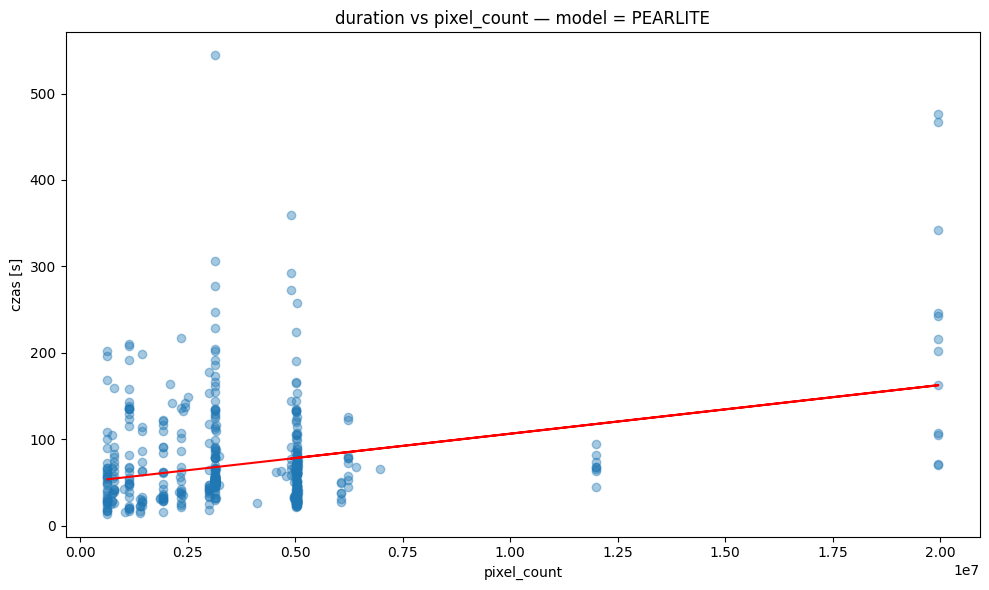

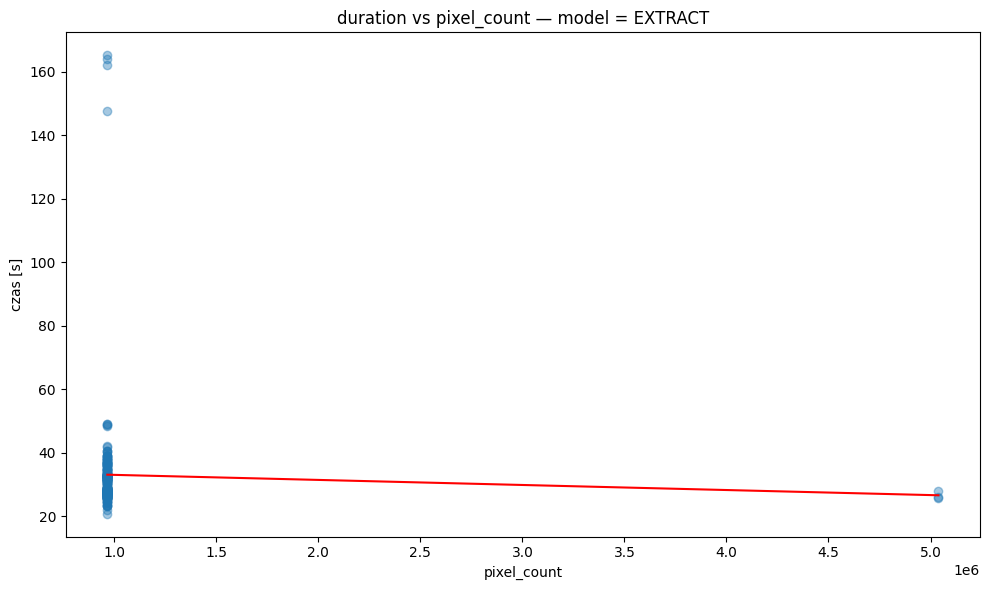

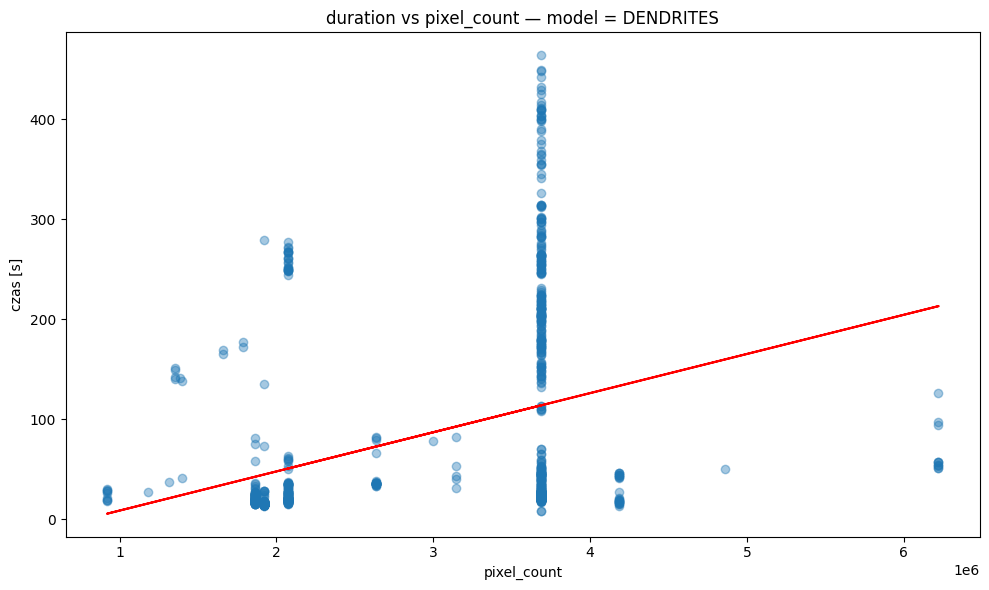

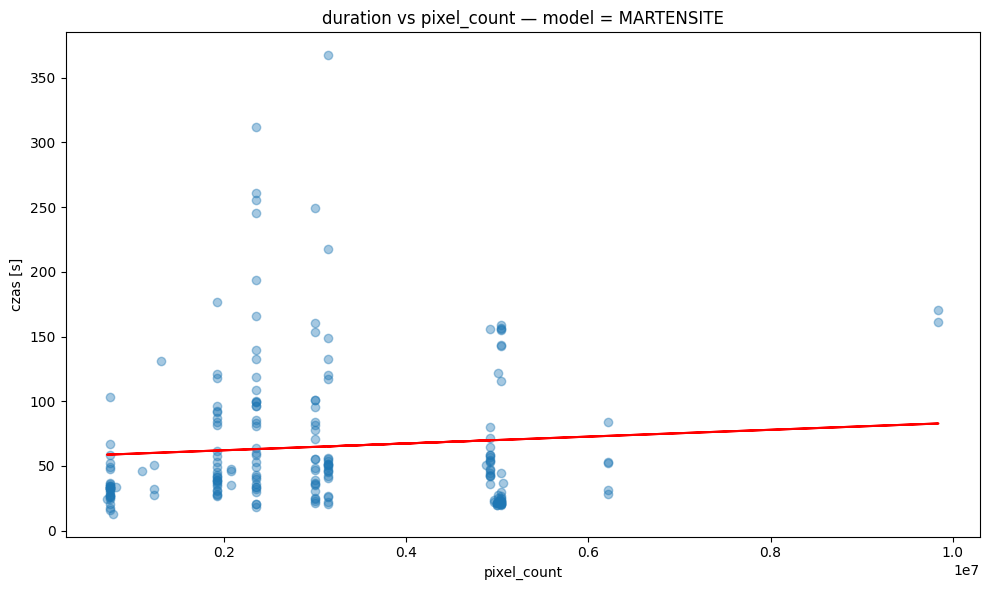

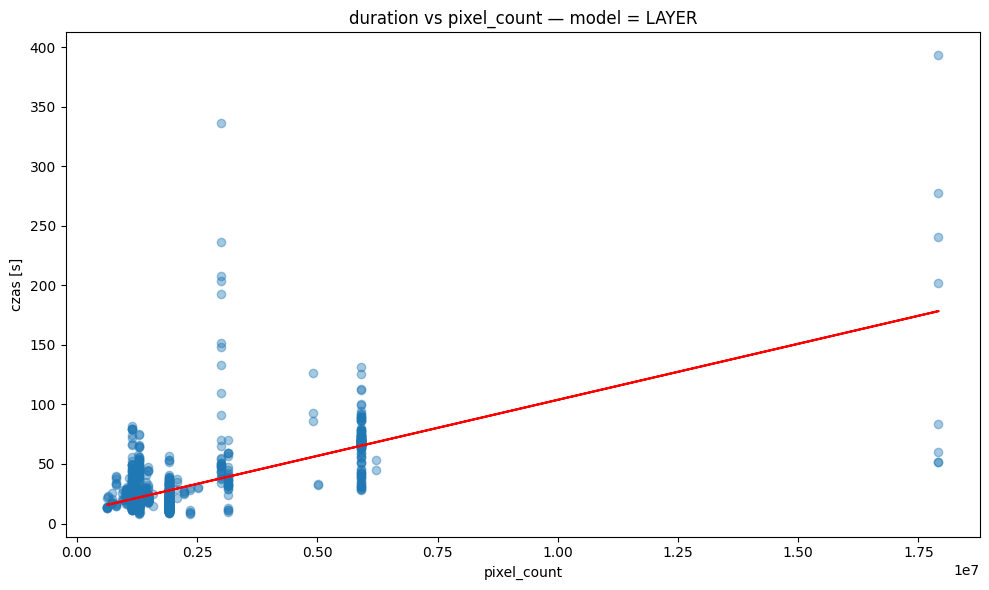

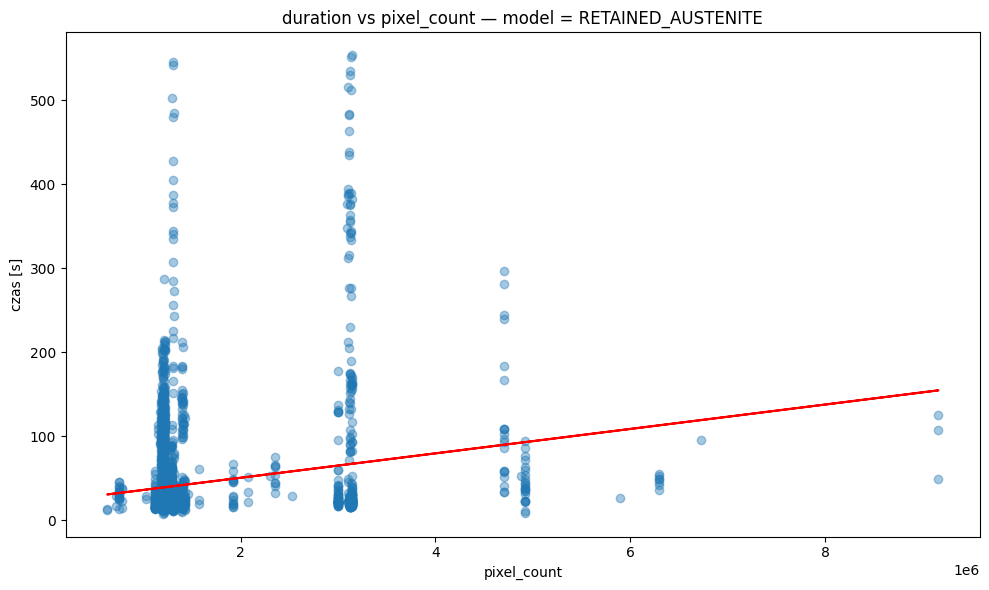

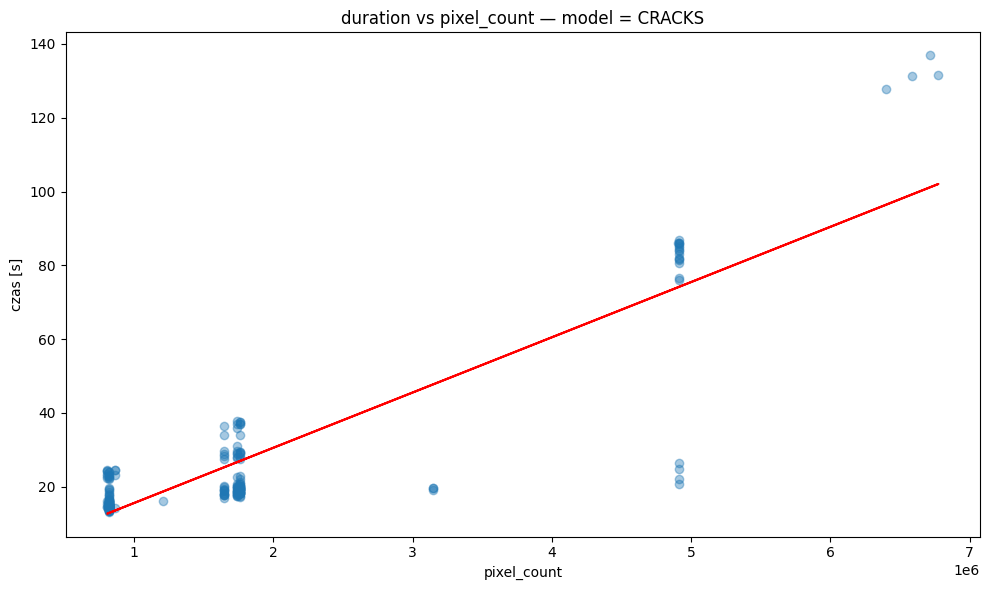

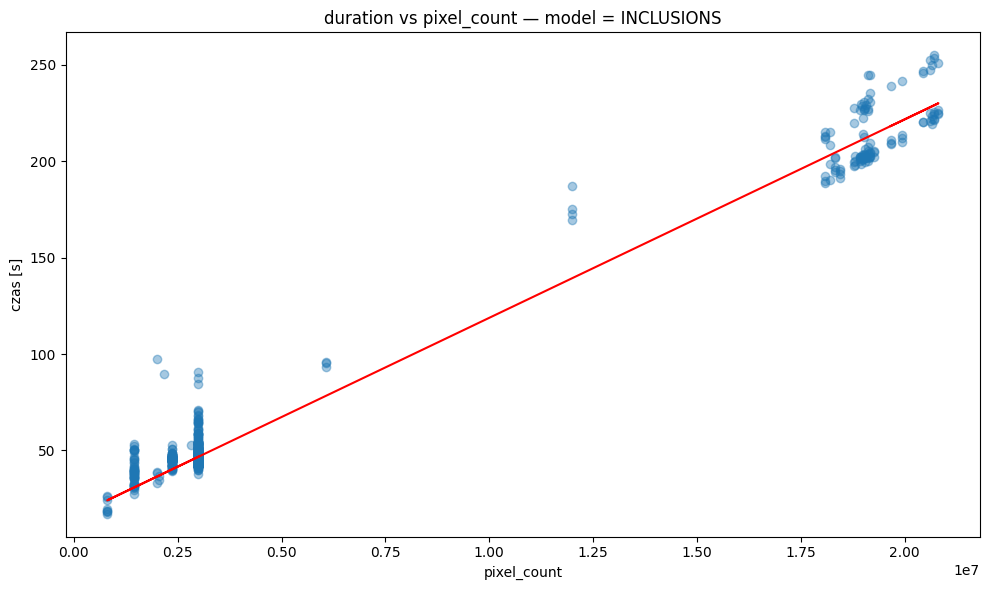

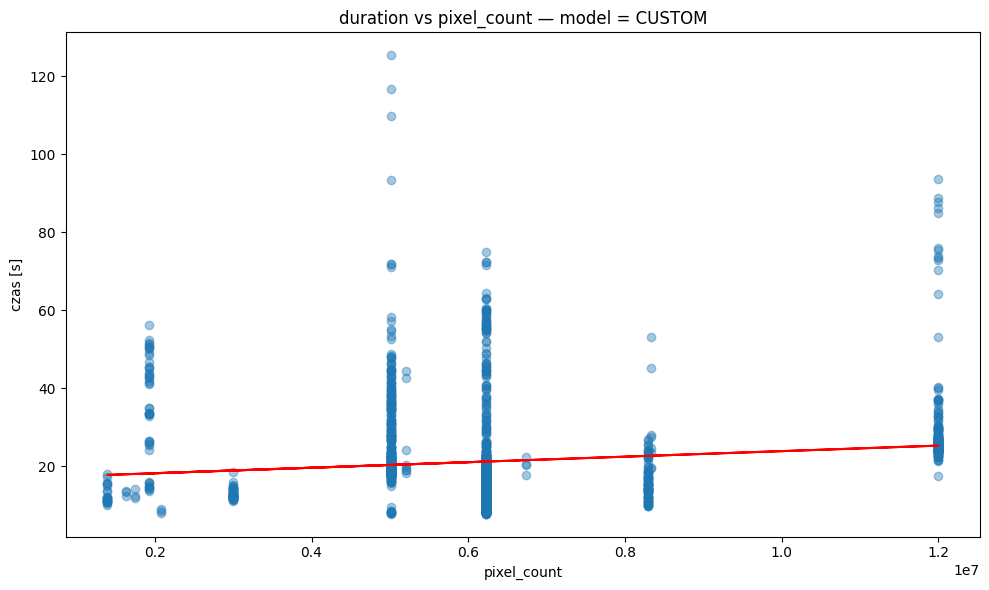

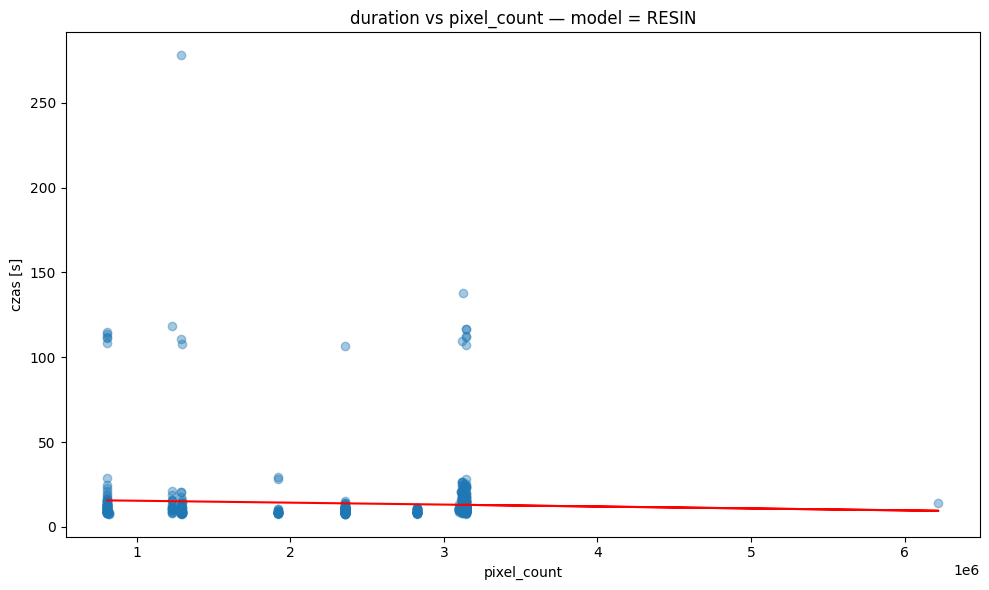

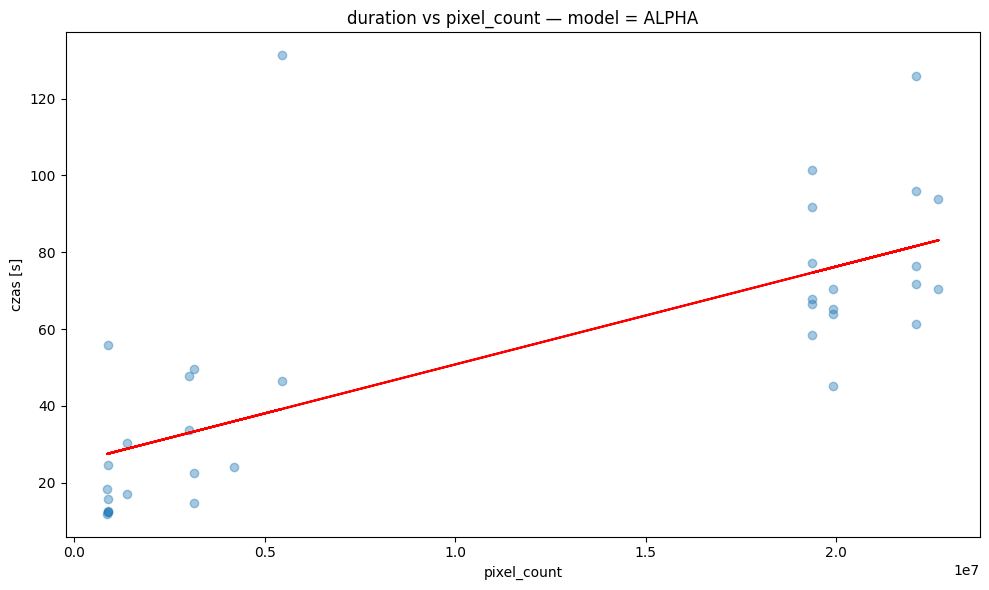

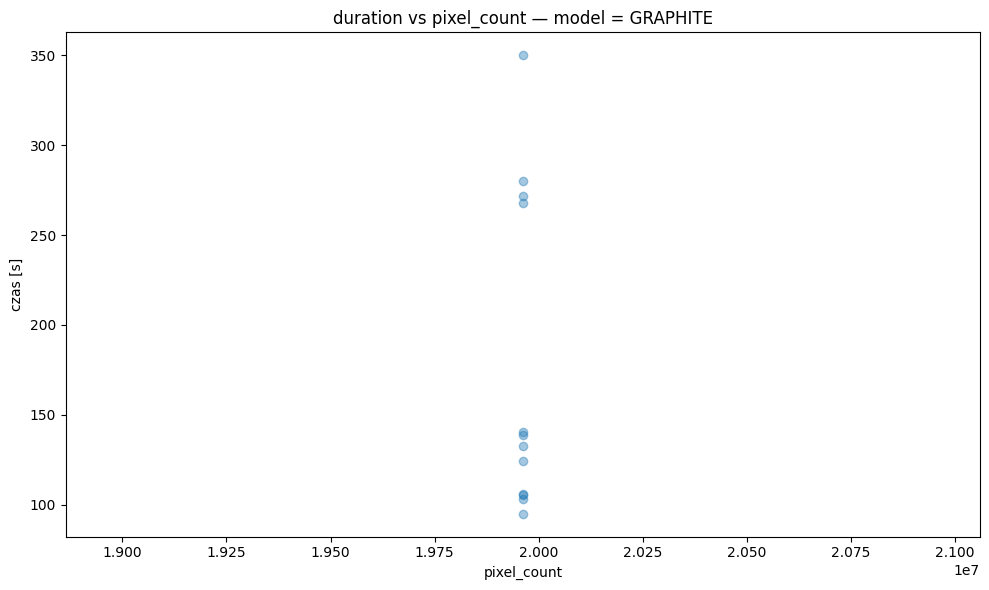

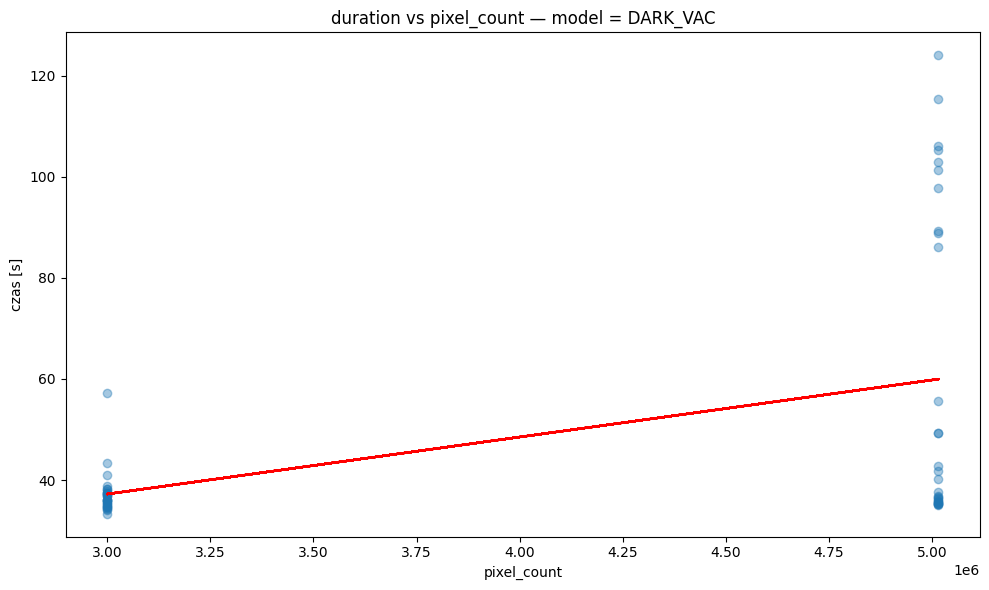

In [ ]:
#To samo teraz dla 1-99% danych
models = df_cut["model_group"].unique()

for m in models:
    subset = df_cut[df_cut["model_group"] == m][
        ["pixel_count", "duration_seconds"]
    ].dropna()

    plt.figure(figsize=(10,6))
    plt.scatter(subset["pixel_count"], subset["duration_seconds"], alpha=0.4)

    # sprawdzamy czy da się policzyć regresję
    if len(subset) > 2 and subset["pixel_count"].nunique() > 1:
        try:
            coef = np.polyfit(subset["pixel_count"], subset["duration_seconds"], 1)
            trend = coef[0] * subset["pixel_count"] + coef[1]
            plt.plot(subset["pixel_count"], trend, color="red")
        except:
            pass

    plt.title(f"duration vs pixel_count — model = {str(m)}")
    plt.xlabel("pixel_count")
    plt.ylabel("czas [s]")
    plt.tight_layout()
    plt.show()


In [ ]:
# Ucinamy 1–99% dla duration i size
d_low = df_new["duration_seconds"].quantile(0.01)
d_high = df_new["duration_seconds"].quantile(0.99)

s_low = df_new["size"].quantile(0.01)
s_high = df_new["size"].quantile(0.99)

df_cut_size = df_new[
    (df_new["duration_seconds"] >= d_low) &
    (df_new["duration_seconds"] <= d_high) &
    (df_new["size"] >= s_low) &
    (df_new["size"] <= s_high)
].copy()

print("Przed:", len(df_new))
print("Po:", len(df_cut_size))

Przed: 34437
Po: 33119


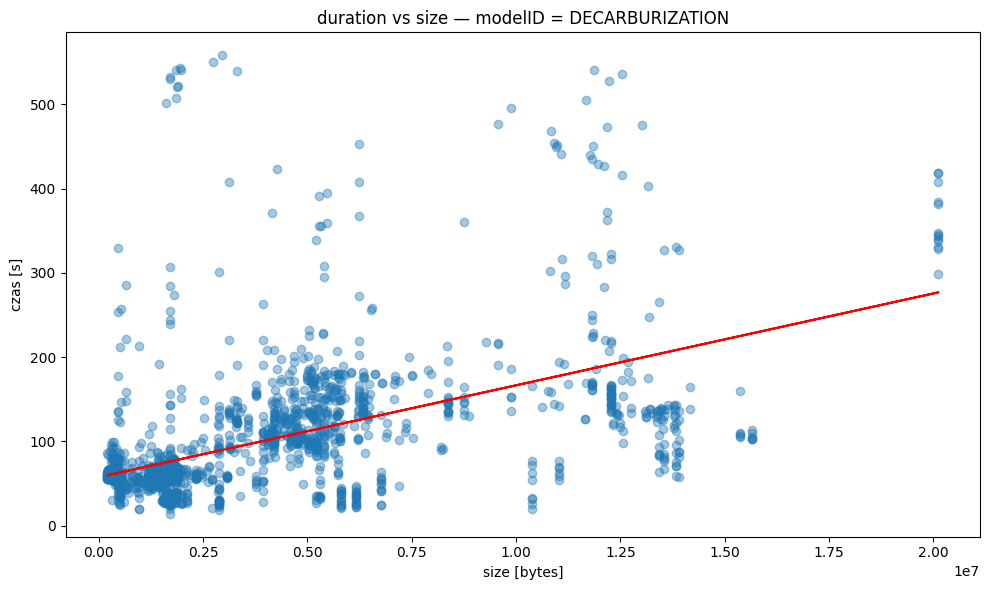

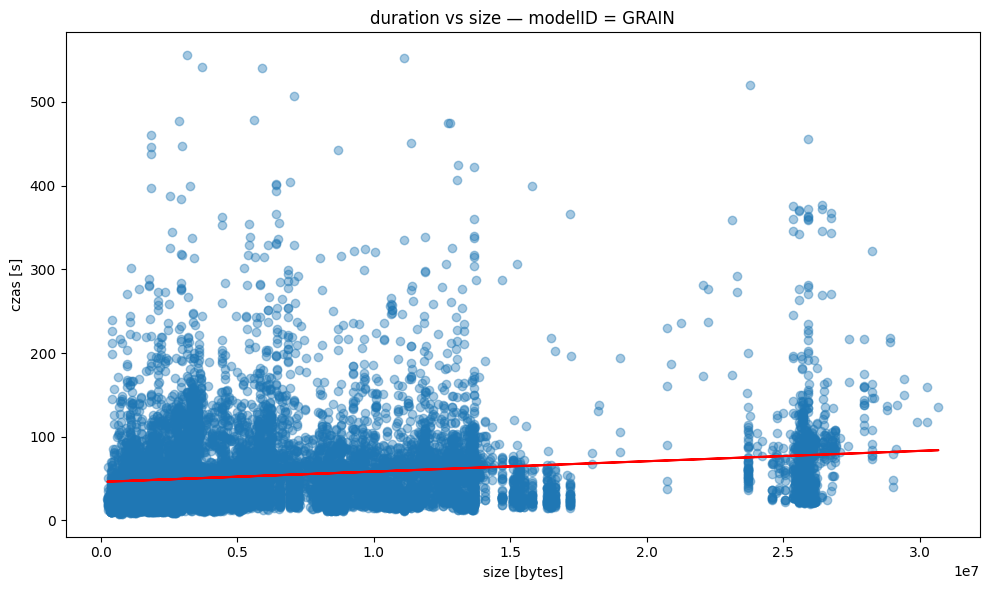

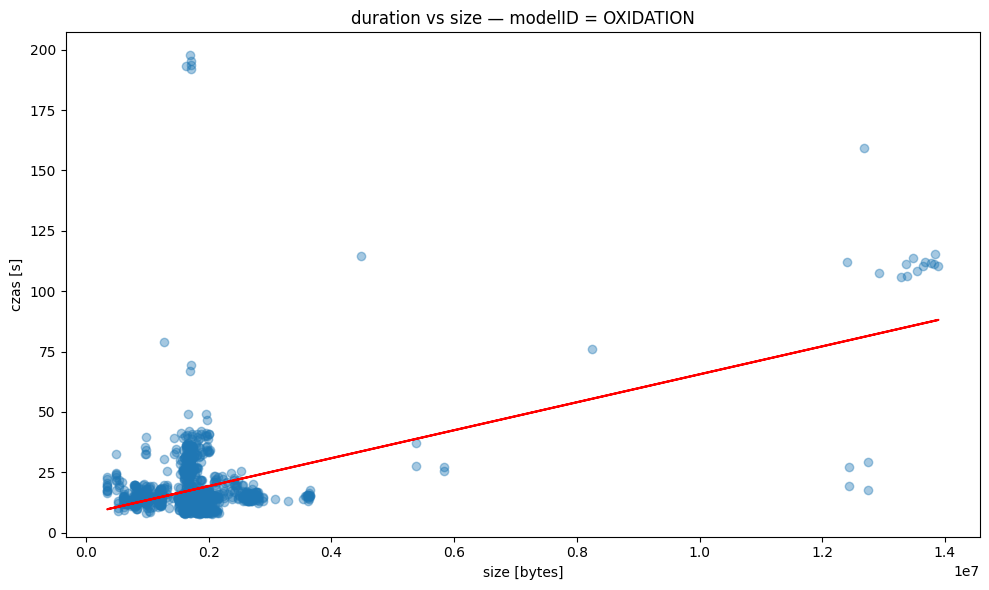

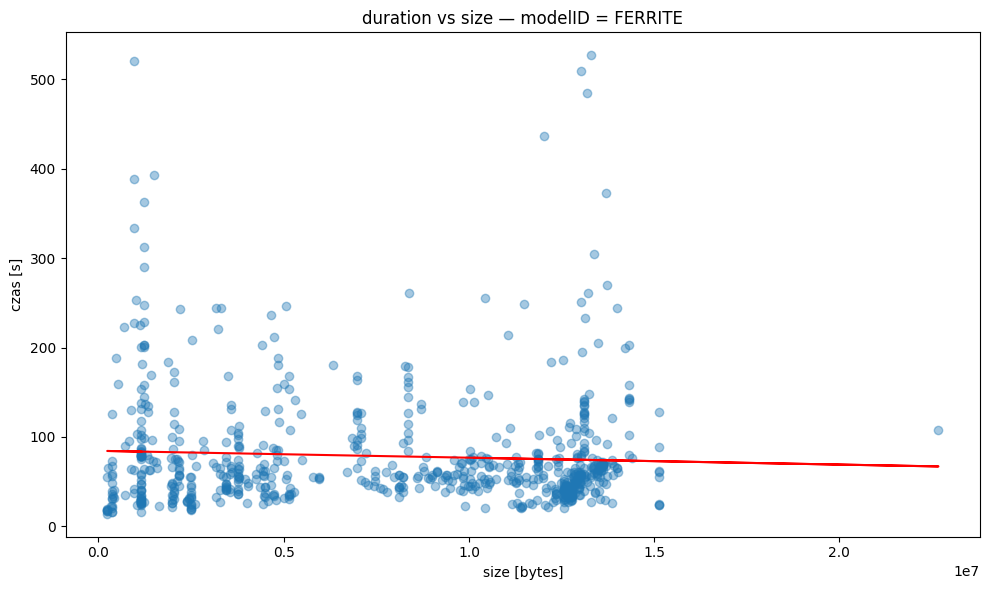

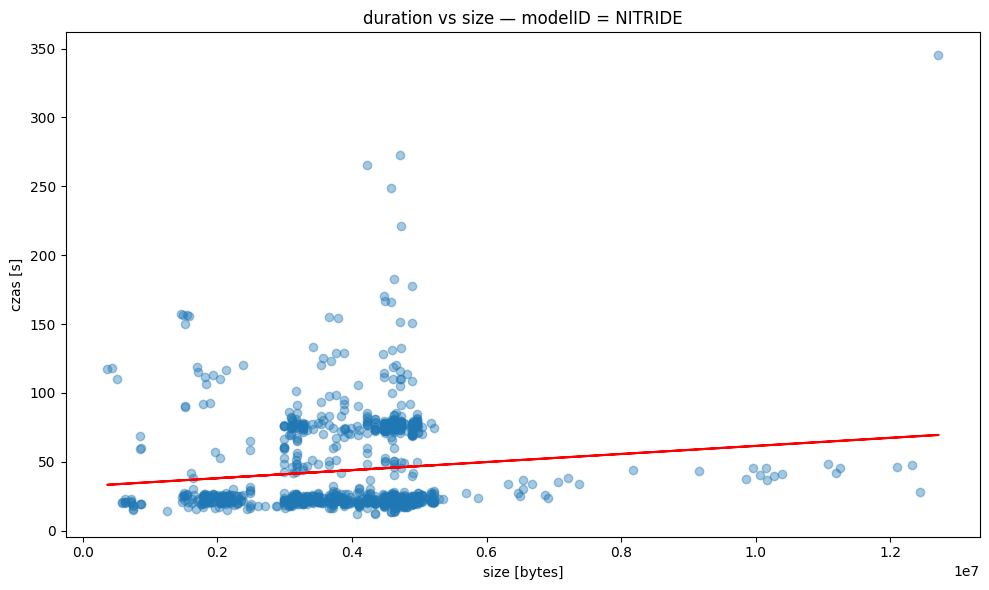

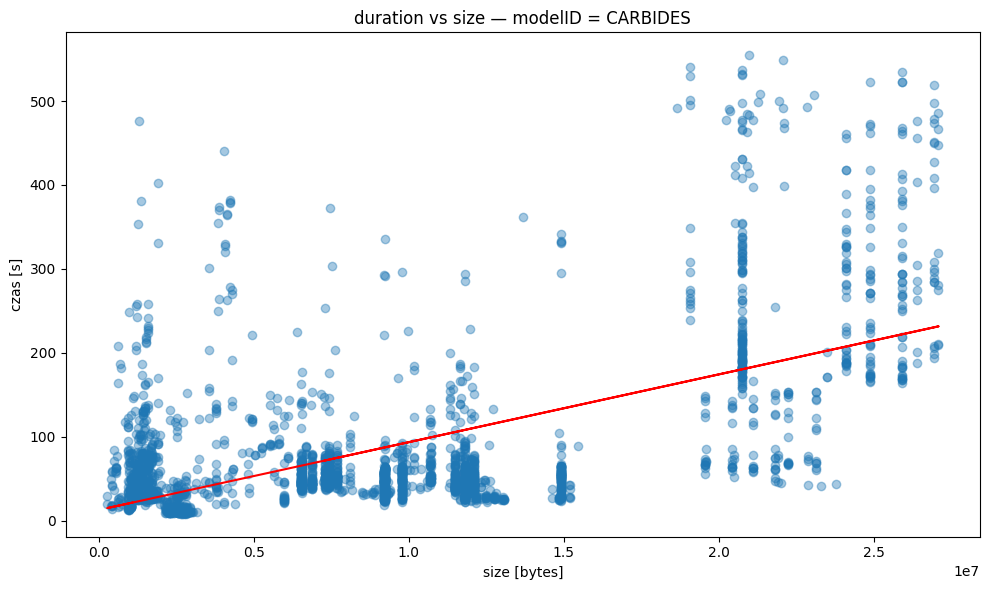

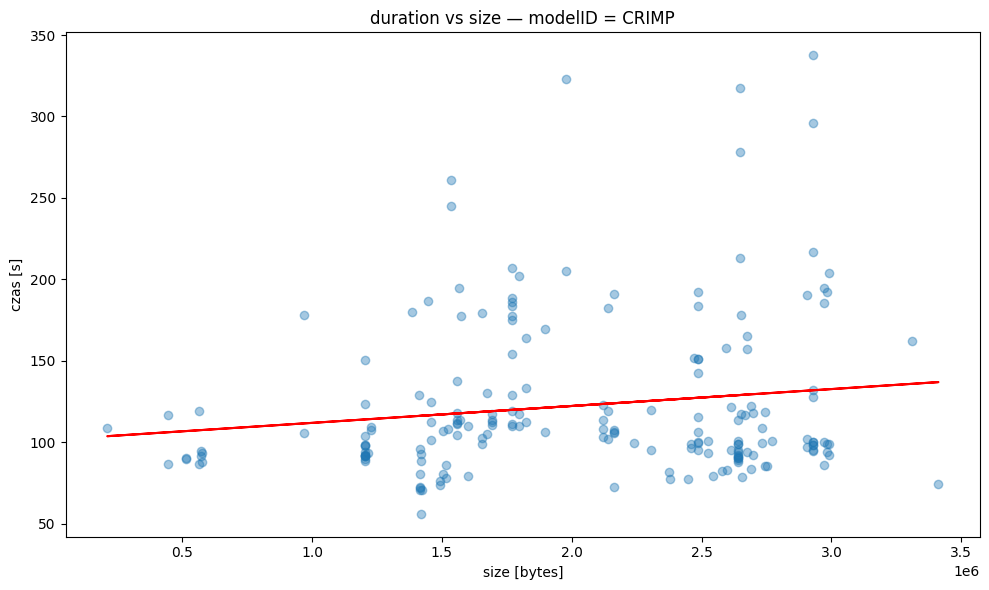

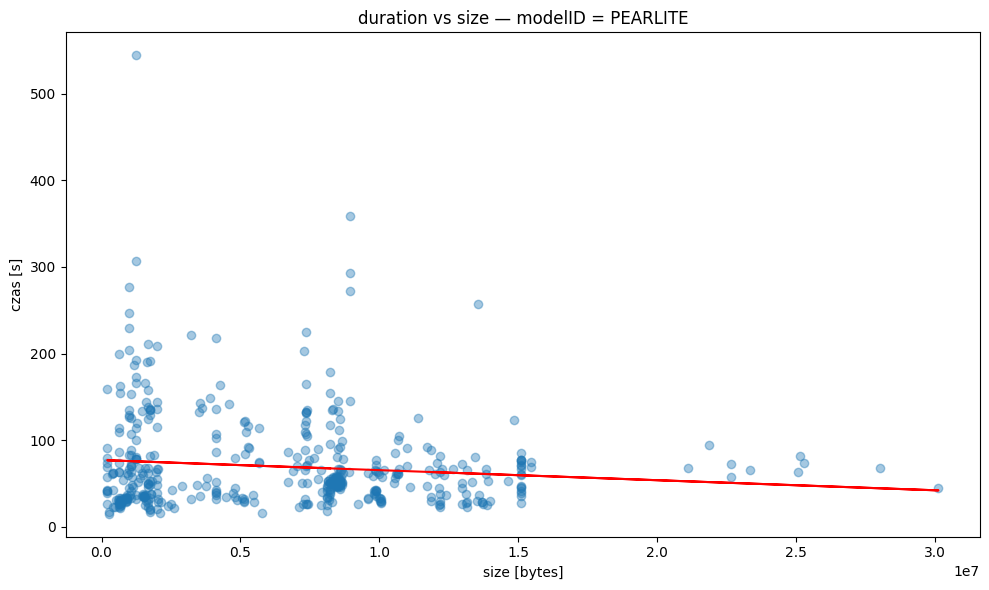

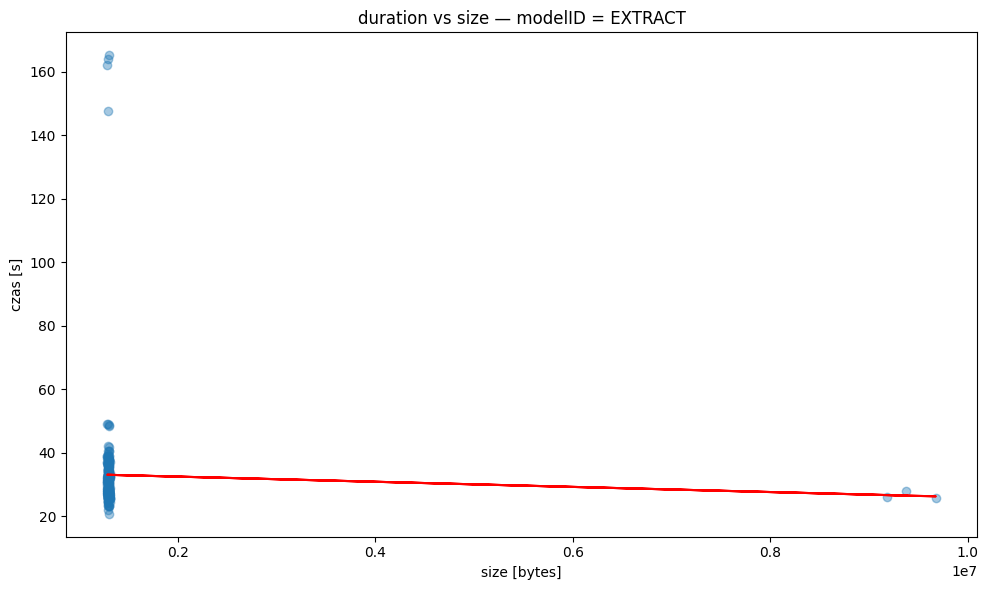

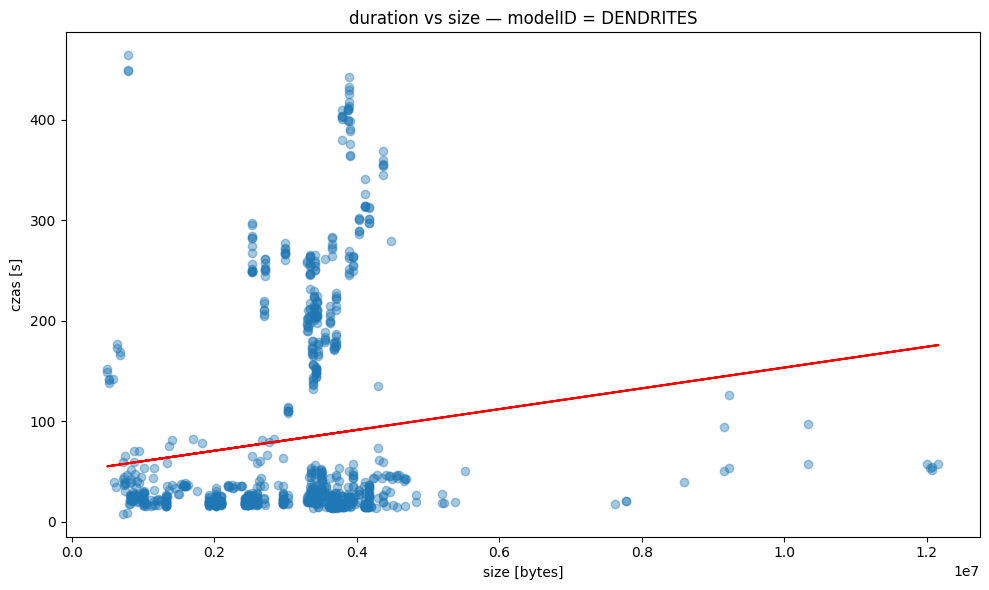

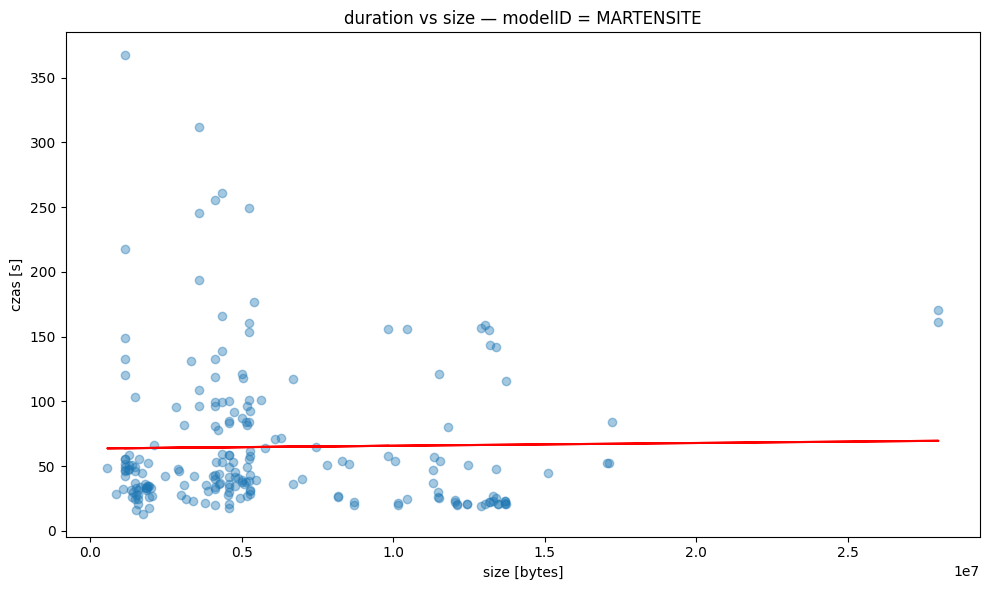

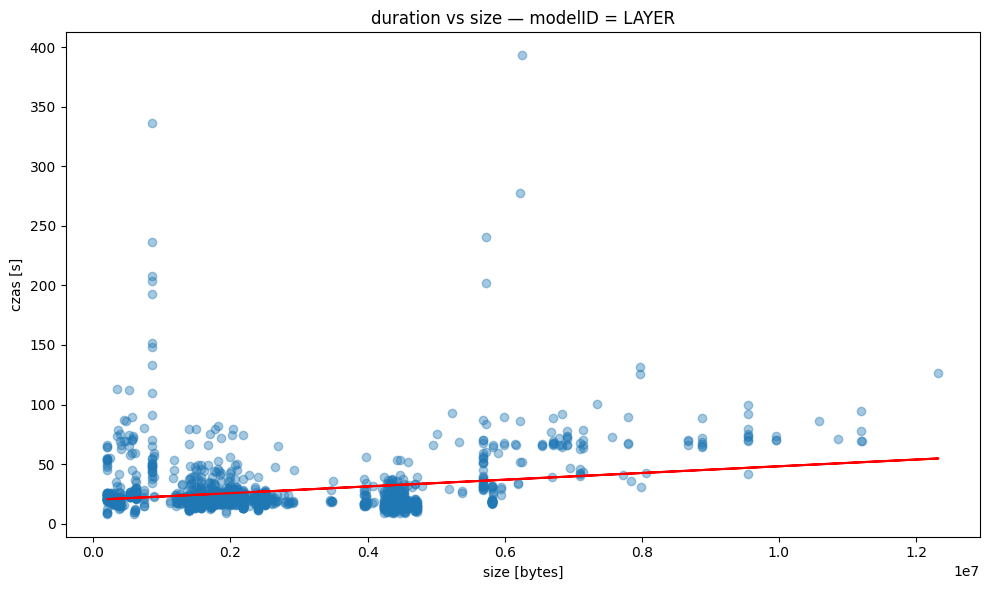

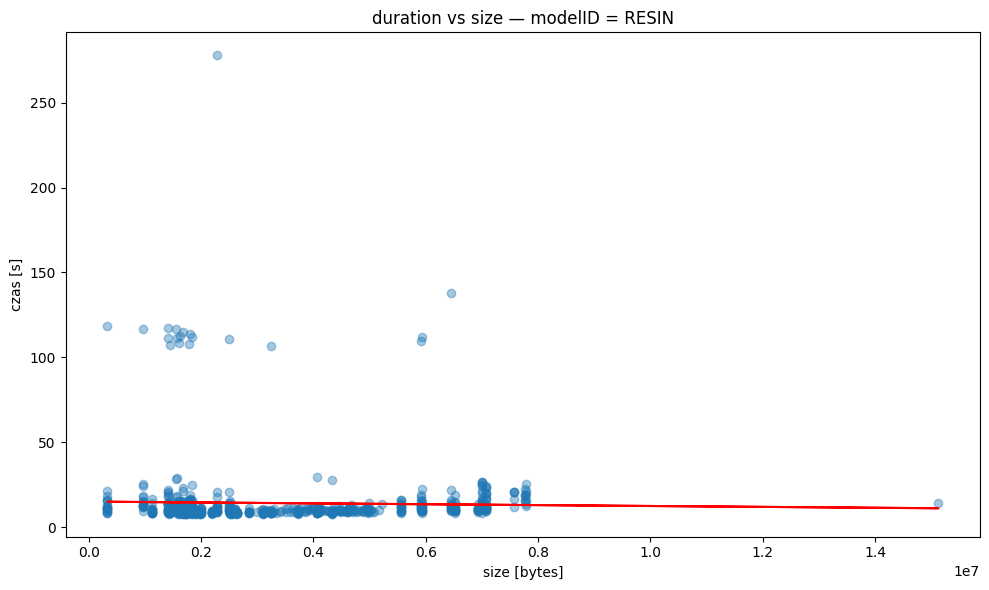

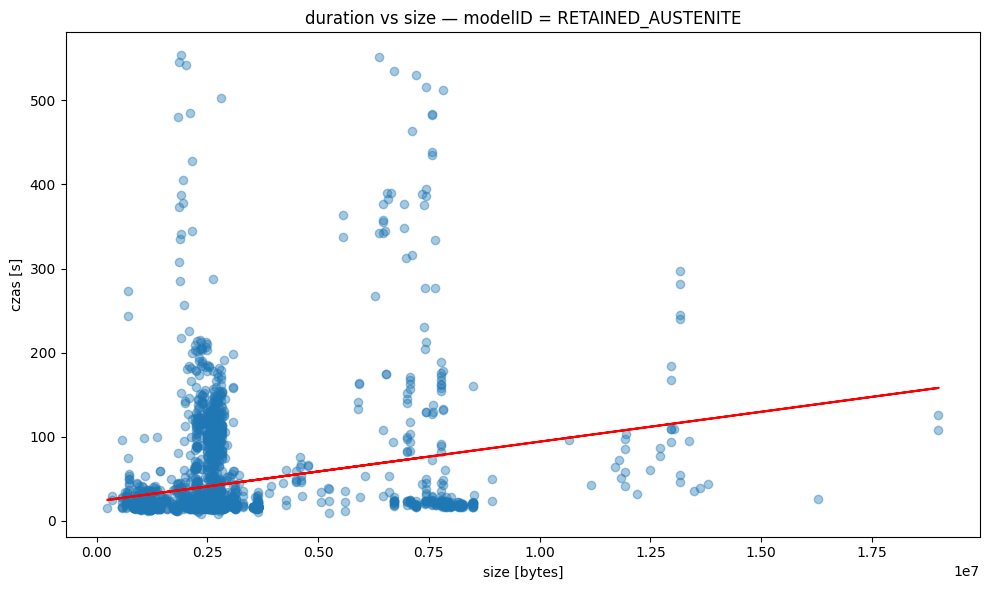

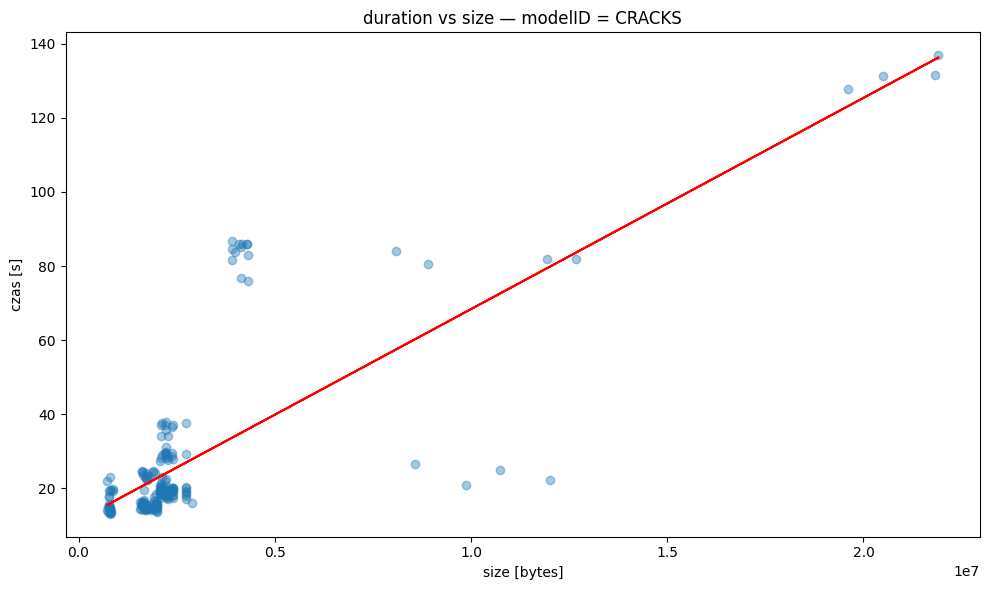

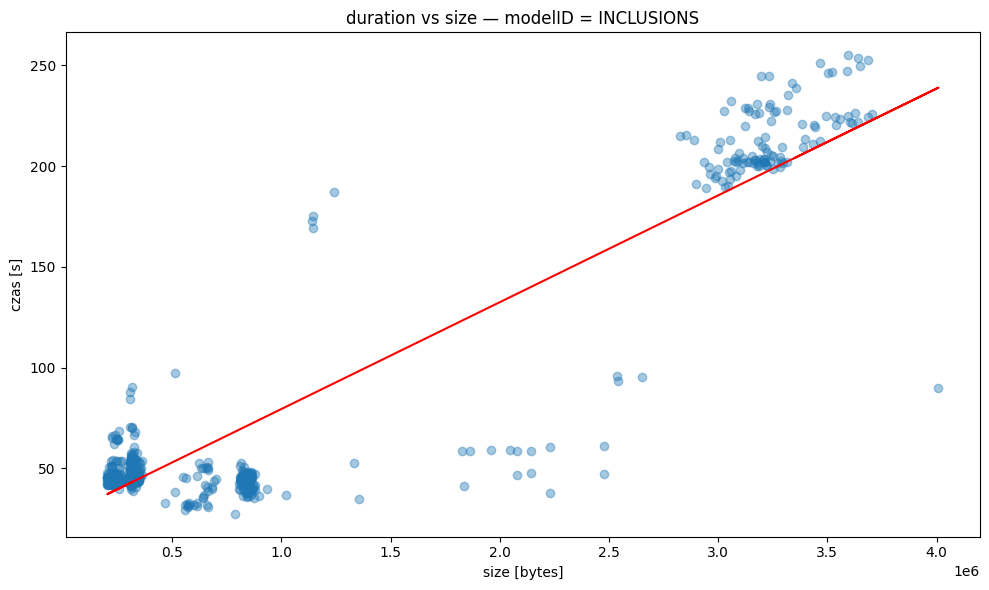

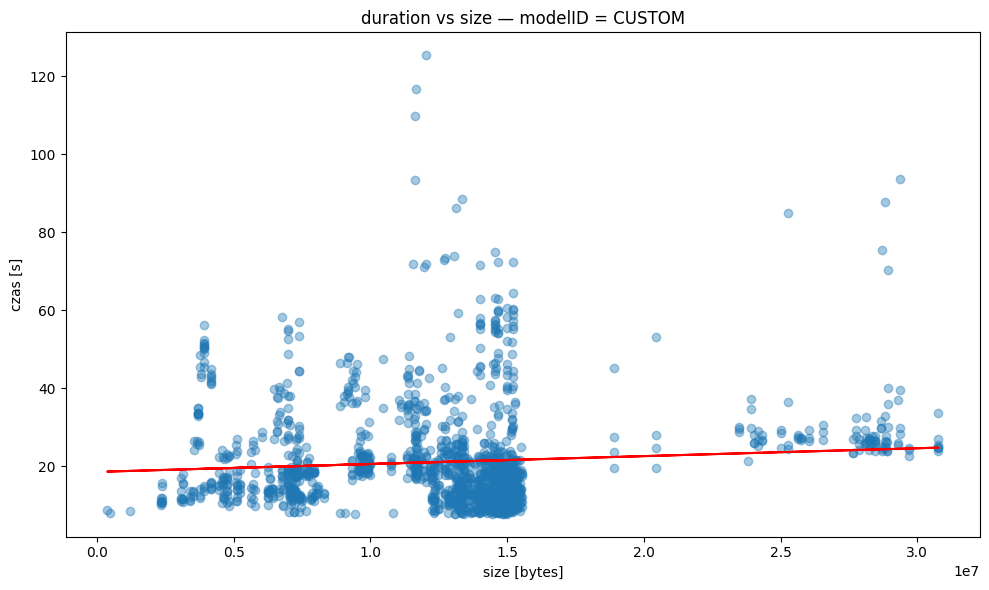

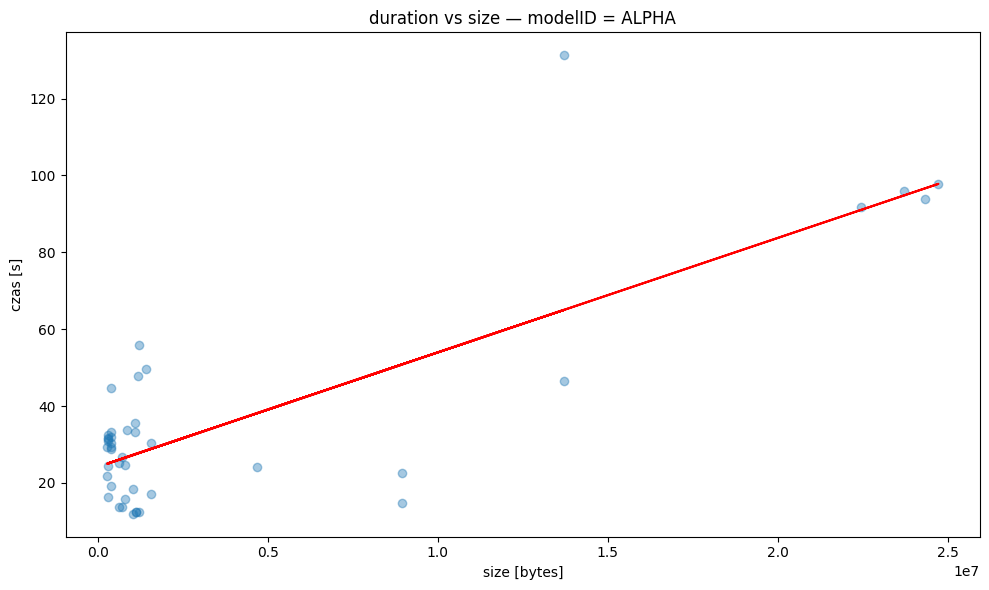

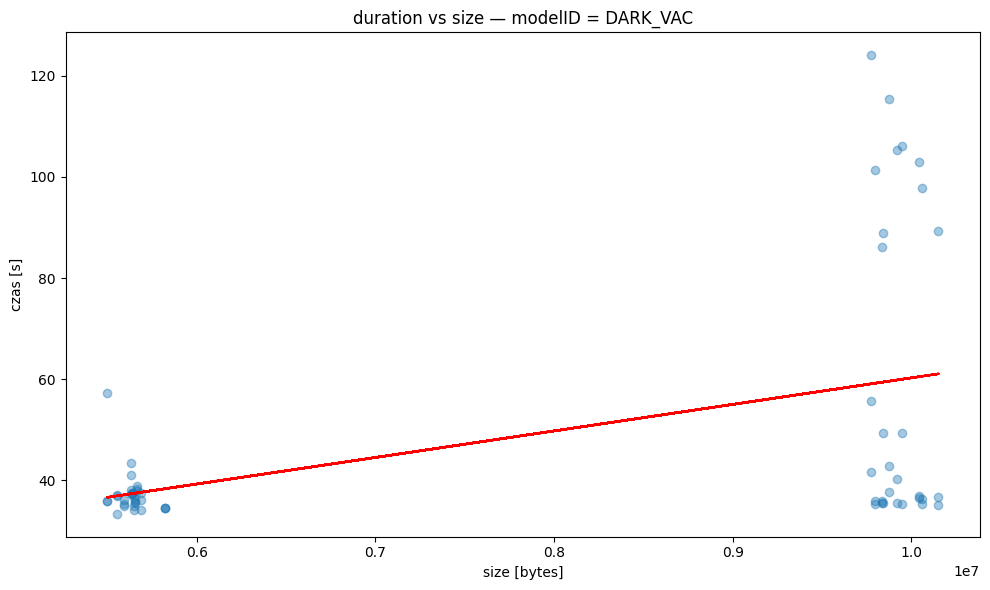

In [ ]:
models = df_cut_size["model_group"].unique()

for m in models:
    subset = df_cut_size[df_cut_size["model_group"] == m][
        ["size", "duration_seconds"]
    ].dropna()

    plt.figure(figsize=(10,6))
    plt.scatter(subset["size"], subset["duration_seconds"], alpha=0.4)

    # sprawdzamy czy da się policzyć regresję
    if len(subset) > 2 and subset["size"].nunique() > 1:
        try:
            coef = np.polyfit(subset["size"], subset["duration_seconds"], 1)
            trend = coef[0] * subset["size"] + coef[1]
            plt.plot(subset["size"], trend, color="red")
        except:
            pass

    plt.title(f"duration vs size — modelID = {str(m)}")
    plt.xlabel("size [bytes]")
    plt.ylabel("czas [s]")
    plt.tight_layout()
    plt.show()

In [ ]:
#Wariancja i odchylenie standardowe per model
model_variability = (
    df_new
    .groupby("model_group")["duration_seconds"]
    .agg(["count", "mean", "median", "std", "var"])
)

model_variability["coef_var"] = (
    model_variability["std"] / model_variability["mean"]
)

model_variability = model_variability.sort_values("coef_var", ascending=False)

model_variability


,count,mean,median,std,var,coef_var
model_group,,,,,,
RETAINED_AUSTENITE,2951,75.860341,18.3510,180.009413,32403.388688,2.372905
NITRIDE,1009,55.043123,25.0130,119.888942,14373.358466,2.178091
LAYER,1711,28.448912,21.1890,50.565814,2556.901549,1.777425
DENDRITES,984,95.155381,26.9600,163.817043,26836.023721,1.721574
GRAIN,14453,63.018730,40.2280,100.946570,10190.209954,1.601850
PEARLITE,565,95.164550,53.4190,143.481181,20586.849249,1.507717
FERRITE,771,94.288441,58.6870,132.977646,17683.054464,1.410328
RESIN,829,13.113177,9.4430,18.044727,325.612181,1.376076
CUSTOM,1835,20.395803,17.1330,27.328537,746.848943,1.339910


In [ ]:
#Jeśli coef_var < 0.3 to znaczy że model jest bardzo stabilny (przewidywalny)
#Jeśli coef_var > 0.3 AND coef_var < 0.6 to znaczy że model jest umiarkowany
#Jeśli coef_var jest > 0.6 to znaczy że model jest niestabilny

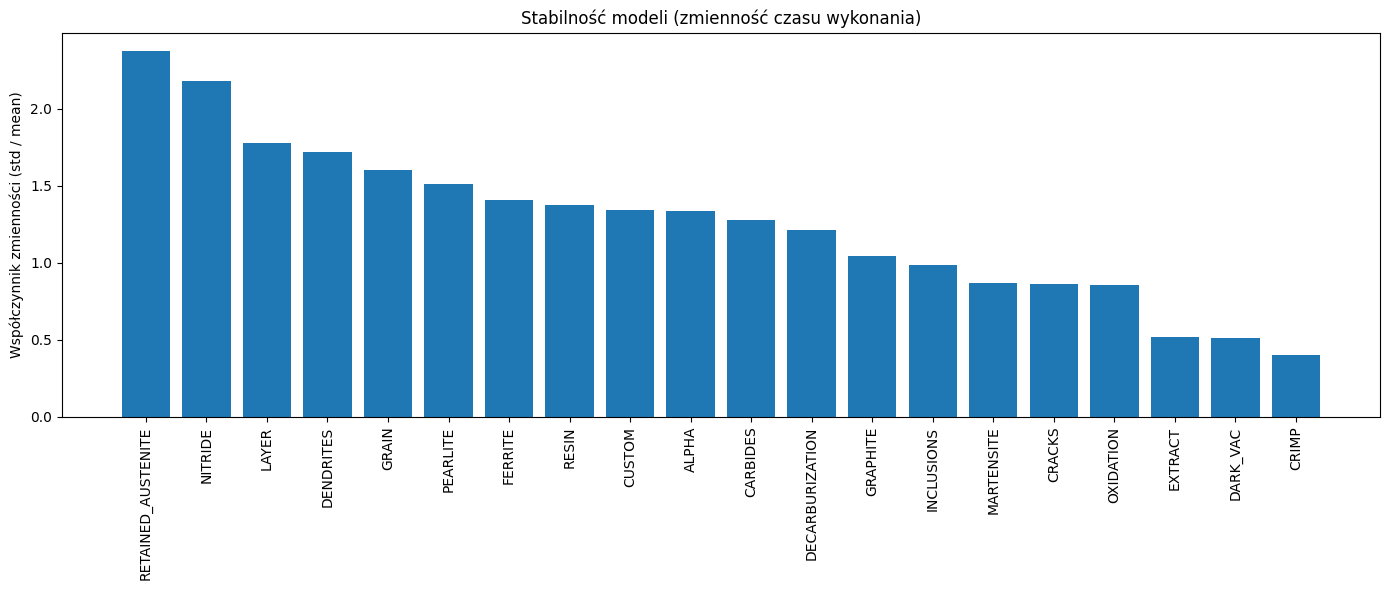

In [ ]:
#wykres stabilności modeli (im mniej tym lepiej)
plt.figure(figsize=(14,6))
plt.bar(
    model_variability.index.astype(str),
    model_variability["coef_var"]
)

plt.xticks(rotation=90)
plt.ylabel("Współczynnik zmienności (std / mean)")
plt.title("Stabilność modeli (zmienność czasu wykonania)")
plt.tight_layout()
plt.show()


In [ ]:
#Sprawdzamy który model jest najszybszy (ile model potrzebuje sekund na przerobienie 1MB danych)
df_new["seconds_per_mpix"] = (
    df_new["duration_seconds"] / (df_new["pixel_count"] / 1_000_000)
)


In [ ]:
#Tabela tych "najszybszych"/"najbardziej wydajnych" modeli
efficiency = (
    df_new
    .groupby("model_group")["seconds_per_mpix"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("mean")
)

efficiency


,count,mean,median,std
model_group,,,,
CUSTOM,1835,3.665556,2.647891,3.464502
RESIN,829,8.831149,4.260882,18.284299
DARK_VAC,61,12.186079,11.882333,4.437707
GRAPHITE,14,14.487026,6.989405,15.114601
INCLUSIONS,1599,15.745661,14.956667,3.304925
CRACKS,211,16.470580,17.163834,5.333257
LAYER,1711,17.812999,14.750898,62.320740
CARBIDES,2771,18.435735,9.004147,34.587332
OXIDATION,1638,18.834139,15.985192,15.223814


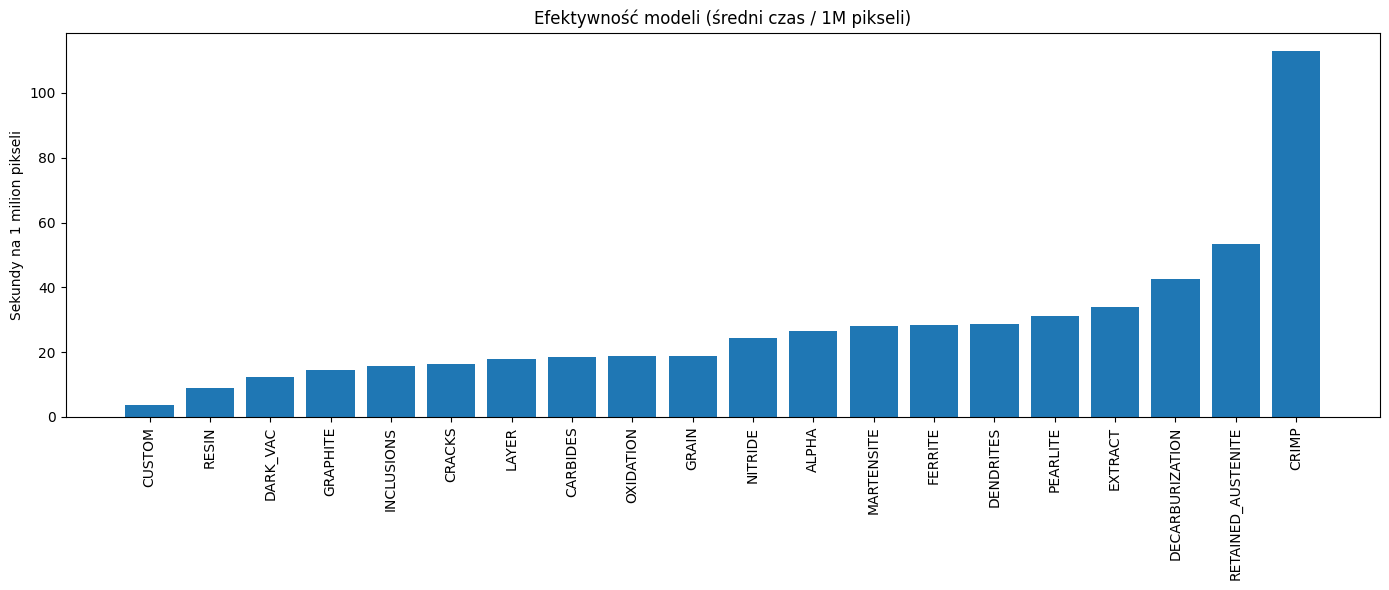

In [ ]:
#Wykres wydajności
plt.figure(figsize=(14,6))
plt.bar(
    efficiency.index.astype(str),
    efficiency["mean"]
)

plt.xticks(rotation=90)
plt.ylabel("Sekundy na 1 milion pikseli")
plt.title("Efektywność modeli (średni czas / 1M pikseli)")
plt.tight_layout()
plt.show()


In [ ]:
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [ ]:
#ETAP 5 - jaki wpływ na wynik ma modelId (wariancja)

In [ ]:
#Wariancja czasu globalna
total_variance = df_new["duration_seconds"].var()
total_variance

12542.684852311935

In [ ]:
#Średnia czasu globalna
global_mean = df_new["duration_seconds"].mean()
global_mean

np.float64(64.40181810262217)

In [ ]:
#Średnia i liczebność per model
group_means = df_new.groupby("model_group")["duration_seconds"].mean()
group_counts = df_new.groupby("model_group")["duration_seconds"].count()
print("\nŚrednie per model: \n")
print(group_means)
print("\nLiczebność per model:\n")
print(group_counts)


Średnie per model: 

model_group
ALPHA                  66.894691
CARBIDES              104.298214
CRACKS                 26.633583
CRIMP                 122.650798
CUSTOM                 20.395803
DARK_VAC               48.411230
DECARBURIZATION       102.007568
DENDRITES              95.155381
EXTRACT                32.978460
FERRITE                94.288441
GRAIN                  63.018730
GRAPHITE              289.187929
INCLUSIONS             58.285979
LAYER                  28.448912
MARTENSITE             64.791173
NITRIDE                55.043123
OXIDATION              17.925902
PEARLITE               95.164550
RESIN                  13.113177
RETAINED_AUSTENITE     75.860341
Name: duration_seconds, dtype: float64

Liczebność per model:

model_group
ALPHA                    68
CARBIDES               2771
CRACKS                  211
CRIMP                   193
CUSTOM                 1835
DARK_VAC                 61
DECARBURIZATION        2318
DENDRITES               984
EXTRACT

In [ ]:
#Jak bardzo średnie modeli różnią się od globalnej średniej.
between_variance = (
    ((group_means - global_mean) ** 2) * group_counts
).sum() / len(df_new)

between_variance

np.float64(691.5293229574986)

In [ ]:
#Procent wyjaśnionej wariancji
explained_ratio = between_variance / total_variance
explained_ratio * 100

np.float64(5.5134074649897)

In [ ]:
#Analiza pokazuje, że zastosowany model  wyjaśnia około 5.5% całkowitej zmienności czasu wykonania.
#Oznacza to, że model ma istotny wpływ na czas wykonania się poszczególnych zadań.
#Pozostała część może zależeć od wcześniej badanych rozmiarów obrazu, ale również od obciążeń systemu (do których nie mamy dostępu ze względu na brak backlogów działającej aplikacji)
#czy charakterystyki danych wejściowych (Tak na prawdę nie wiemy jak "trudne" są niektóre obrazy do przeanalizowania przez konkretne modele)


In [ ]:
#R^2 dla zmiennej ilościowej size
from sklearn.linear_model import LinearRegression
df_size = df_new[["size", "duration_seconds"]].dropna()

X_size = df_size["size"].values.reshape(-1, 1)
y_size = df_size["duration_seconds"].values

model_size = LinearRegression()
model_size.fit(X_size, y_size)

r2_size = model_size.score(X_size, y_size)
r2_size

0.03964852822574216

In [ ]:
#Jak widać rozmiar obrazu (zmienna size) tłumaczy około 3.9% wariancji

In [ ]:
#R^2 dla zmiennej ilościowej pixel_count
df_pixel = df_new[["pixel_count", "duration_seconds"]].dropna()

X_pixel = df_pixel["pixel_count"].values.reshape(-1, 1)
y_pixel = df_pixel["duration_seconds"].values

model_pixel = LinearRegression()
model_pixel.fit(X_pixel, y_pixel)

r2_pixel = model_pixel.score(X_pixel, y_pixel)
r2_pixel

0.10388860892714302

In [ ]:
#Jak widać rozmiar obrazu (zmienna size) tłumaczy około 10.3% wariancji

In [ ]:
#R^2 dla zmiennej ilościowej complexity
df_complexity = df_new[["complexity", "duration_seconds"]].dropna()

X_complexity = df_complexity["complexity"].values.reshape(-1, 1)
y_complexity = df_complexity["duration_seconds"].values

# model
model_complexity = LinearRegression()
model_complexity.fit(X_complexity, y_complexity)

# R^2
r2_complexity = model_complexity.score(X_complexity, y_complexity)
r2_complexity

0.055253538211428865

In [ ]:
#5.5% wyjaśnionej wariancji

In [ ]:
#macierz korelacji dla wybranych zmiennych
corr_df = df_new[
    ["duration_seconds", "pixel_count", "compression_ratio", "complexity","size"]
].dropna()

correlation_matrix = corr_df.corr()
correlation_matrix

,duration_seconds,pixel_count,compression_ratio,complexity,size
duration_seconds,1.000000,0.322318,-0.018950,0.235061,0.199119
pixel_count,0.322318,1.000000,0.013446,0.722250,0.787600
compression_ratio,-0.018950,0.013446,1.000000,-0.050124,0.429884
complexity,0.235061,0.722250,-0.050124,1.000000,0.585387
size,0.199119,0.787600,0.429884,0.585387,1.000000


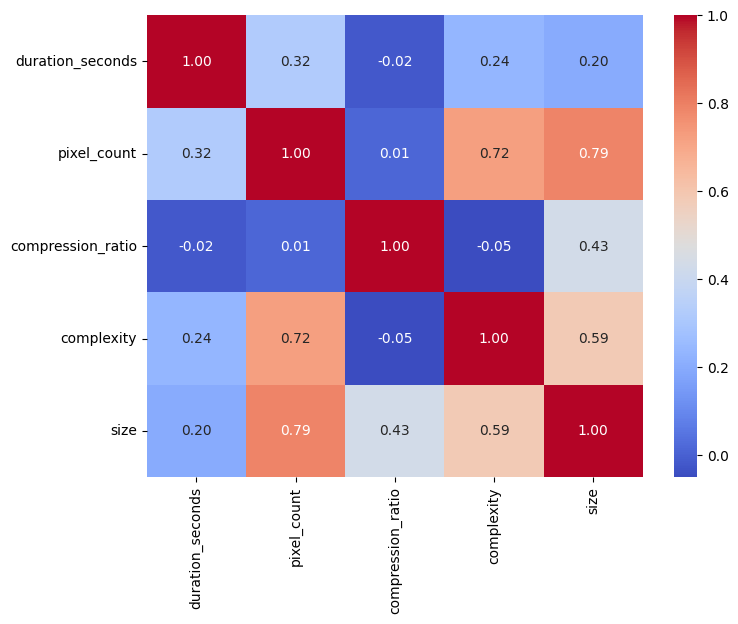

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

In [ ]:
#Jak można zauważyć z przygotowanej statystyki, zmienne takie jak size, pixel_count czy modelId tłumaczą w niewielkim stopniu czas wykonania się poszczególnych zadań
#Może to wynikać z różnych czynników takich jak fakt, iż część obrazów jest skalowanych przed przetwarzaniem lub działają na stałem rozdzielczości (resize).
#Ponadto wpływ na analizę obrazów mogą mieć takie czynniki jak obciążenie systemu, armitektura poszczególnych modeli lub moc obliczeniowa zapewniona od dostawców systemów chmmurowych


In [ ]:
#Dzięki zastosowanej statystyce widzimy jak wyglądają zmienne dostarczone w formie danych historycznych i w jaki sposób tłumaczą czas wykonania.
#Aby przewidywać czas wykonania się poszczególnych zadań przechodzimy do etapu 1 jakim jest offline learning.
#W etapie pierwszym spróbujemy zastosować takie modele jak: regresja wielowymiarowa, random forest oraz neural network w celu znalezienia jak najepszego modelu do przewidywania czasu wykonania się zadań w heterogenicznym systemie